# High-z Galaxy SAM: Dust Attenuation and UV Luminosity Functions

Semi-Analytic Model (SAM) for high-redshift galaxies (default z=10, also tested at z=7).
Builds star formation histories from halo accretion, tracks dust mass from SN yields,
and computes UV/IR observables including dust attenuation and luminosity functions.

**Figures produced:**
0. Instantaneous SFR vs M_h (GUREFT vs LS22 accretion rates)
1. 4-panel galaxy evolution: SFH, M_star, M_dust, M_d/M_star
2. Intrinsic M_UV vs M_star with JWST/REBELS data
3. κ(λ): MW vs stellar dust opacity curves with grain-size inset
3b. τ_V build-up vs galaxy age with JWST/REBELS observations
4. Normalised attenuation curves A_λ/A_V (MW vs stellar dust, two geometries)
5. M_UV–M_star with dust attenuation (mixed sphere vs point source, ε/y_d grid)
6. Σ_d and M_UV PDFs: galaxy-to-galaxy scatter vs turbulent clumping (Mach 10–300)
7. UV LF — Uniform ISM, MW dust (+ separate IR LF at z=7)
8. UV LF — Uniform ISM, Stellar dust (+ separate IR LF at z=7)
9. UV + IR LF — Turbulent ISM, MW and Stellar dust (two-panel at z=7)
-. Galaxy half-light radius r_d vs M_UV
-. Kennicutt vs SB99 L_1500 comparison


## 1. Setup and Imports

Import required libraries and define utility functions for analysis.

In [53]:
from functools import partial
from pathlib import Path

import dust_jwst_highz.constants as const
import numpy as np
import pandas as pd
import yaml
from astropy.cosmology import z_at_value
from dust_jwst_highz.model.cosmology import cosmo
from dust_jwst_highz.model.dust import (
    attenuation_curve_li08,
    attenuation_curve_rt,
    attenuation_curve_sommovigo25,
    compute_g_lambda,
    compute_mdust_steps,
    disk_scale_length,
    dust_temp_from_lir,
    grain_size_dist,
    kappa_lambda,
    optical_depth,
    seedavg_lir,
    small_carbonaceous_grain_dist,
    stellar_grain_size_dist,
    transmission_sphere,
    transmission_sphere_mixed,
)
from dust_jwst_highz.model.halo import halo_mass_accretion_rate, log_halo_mass_function, virial_radius
from dust_jwst_highz.model.ism import density_compression_ratio, lognormal_variance_from_mach, sample_surface_density
from dust_jwst_highz.model.luminosity import (
    compute_dotnion_steps,
    compute_l1500_steps,
    greybody_fnu,
    l1500_lambda_to_lnu,
    l1500_to_muv_conv,
)
from dust_jwst_highz.data import load_dust_constants, save_dust_constants
from dust_jwst_highz.model.star_formation import halo_to_stellar_mass, star_formation_history, star_formation_rate
from dust_jwst_highz.utils import enforce_monotonic, find_nearest
from dust_jwst_highz.visualization import plot_lf_data, truncate_colormap
from matplotlib import colors, gridspec
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.transforms import blended_transform_factory
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy import special, stats
from scipy.signal import savgol_filter
from scipy.stats import gaussian_kde, norm

In [54]:
# Data Loading
try:
    _HERE = Path(__file__).resolve().parent  # script mode
except NameError:
    _HERE = Path().resolve()  # notebook/interactive mode (run from notebooks/ dir)
DATA_DIR = (_HERE / "../data").resolve()
OUTPUT_DIR = (_HERE / "../outputs").resolve()

dust_pah = pd.read_csv(DATA_DIR / "dust_PAH.csv", comment="#")
dust_graphite = pd.read_csv(DATA_DIR / "dust_graphite.csv", comment="#")
dust_silicate = pd.read_csv(DATA_DIR / "dust_silicate.csv", comment="#")
wavelengths = dust_graphite["wavelength"].unique()[::-1] * 1e4  # µm → Å

# Q_abs: wavelength and grain-size-dependent absorption efficiency
# Shape should be [len(wavelengths) * (len(a) - 1)], flattened
Qabs = np.loadtxt(DATA_DIR / "Q_abs_Draine_silicates.csv", unpack=True, delimiter=",")

# Global font style and size (matches main branch librerie.py / STIX serif convention)
plt.rcParams.update({
    "font.size": 16,
    "font.family": "serif",
    "mathtext.fontset": "stix",
})

# Create custom colormap
custom_colormap_base = plt.cm.coolwarm
custom_colormap = truncate_colormap(custom_colormap_base, 0.1, 1.0)

## 2. Load Starburst99 Tables

Load Starburst99 (SB99) stellar population synthesis tables for instantaneous burst models:
- Metallicity: Z=0.001 (1/10 Z_sun)
- IMF: Salpeter (1-100 M_sun)
- Data: SN rate, ionizing photon rate, L1500 UV luminosity

These tables are convolved with the star formation history to compute time-dependent properties.

In [55]:
# Load SB99 tables: instantaneous burst, Z=0.001, Salpeter IMF (1-100 Msun)
# All three instantaneous-burst files share the same time column (verified).
_snr = pd.read_csv(DATA_DIR / "snr_inst_Z001.csv")
_nion = pd.read_csv(DATA_DIR / "Ni_inst_Z001.csv")
_l1500_inst = pd.read_csv(DATA_DIR / "L1500_inst_Z001.csv")
sb99_inst = pd.DataFrame(
    {
        "time_yr": _snr["time_yr"],
        "log_snr": _snr["log_snr"],
        "log_dot_nion": _nion["log_nion"],
        "l1500": _l1500_inst["log_l1500"],
    }
)
del _snr, _nion, _l1500_inst

# L1500 continuous SFR track (different time grid from instantaneous)
_cont = pd.read_csv(DATA_DIR / "L1500_cont_Z001.csv")
sb99_cont = pd.DataFrame(
    {
        "time_yr": _cont["time_yr"],
        "l1500": _cont["log_l1500"],
    }
)
del _cont

# Convenience arrays for downstream function calls
time_yr = sb99_inst["time_yr"].values
log_snr_yr = sb99_inst["log_snr"].values
time_yr_nion = sb99_inst["time_yr"].values
log_dot_nion = sb99_inst["log_dot_nion"].values
time_yr_l1500 = sb99_inst["time_yr"].values
l1500_sb99 = sb99_inst["l1500"].values
time_yr_l1500_cont = sb99_cont["time_yr"].values
l1500_sb99_cont = sb99_cont["l1500"].values

In [56]:
with open(DATA_DIR / "wd01_mw_gsd_params.yaml") as f:
    WD01_MW_PARAMS = yaml.safe_load(f)


rv = "3.1"
dcase = "A"
bc_idx = 2
bc = bc_idx * 1.0e-5

p = WD01_MW_PARAMS[rv][dcase][bc_idx]

graphite_params = p["graphite"].copy()
graphite_params["at"] *= const.micron
graphite_params["ac"] *= const.micron

silicate_params = p["silicate"].copy()
silicate_params["at"] *= const.micron
silicate_params["ac"] = 0.1 * const.micron  # WD01 adopt a_c,s = 0.1 µm for MW

In [58]:
radius_small = 0.001  # 0.001 micron, smallest in Draine table
radius_big = 0.1585  # 0.3 micron, where Hirashita young dust centred

# Densities
rho_carb = 2.24  # graphite
rho_sil = 3.5  # silicate


radius_graphite = dust_graphite["radius"].unique() * const.micron
radius_silicate = dust_silicate["radius"].unique() * const.micron
# -----------------------------
# 2. Choose two grain sizes
# -----------------------------
a_grid = np.logspace(np.log10(3.5e-8), np.log10(1e-4), 500)
phi_graphite_star = stellar_grain_size_dist(radius_graphite, a0_cm=1e-5, sigma=0.47)  # a0 = 0.1 μm
phi_silicate_star = stellar_grain_size_dist(radius_silicate, a0_cm=1e-5, sigma=0.47)

# convert φ(a) → (1/n_H) dn/da with the same D as MW
factor_graphite = const.mean_mol_weight * const.m_p * const.dust_ratio_mw / ((4.0 * np.pi / 3.0) * rho_carb)
factor_silicate = const.mean_mol_weight * const.m_p * const.dust_ratio_mw / ((4.0 * np.pi / 3.0) * rho_sil)

graphite_dist_star = factor_graphite * phi_graphite_star  # same units as dn_da_C
silicate_dist_star = factor_silicate * phi_silicate_star  # same units as dn_da_Si


radius_graphite = dust_graphite["radius"].unique() * const.micron

graphite_dist = grain_size_dist(
    radius_graphite,
    **graphite_params,
    d_func=partial(small_carbonaceous_grain_dist, bc=bc),
)
kappa_c_abs = kappa_lambda(
    radius_graphite,
    dust_graphite.pivot(index="radius", columns="wavelength", values="Q_abs").values,
    graphite_dist,
)
kappa_c_sca = kappa_lambda(
    radius_graphite,
    dust_graphite.pivot(index="radius", columns="wavelength", values="Q_sca").values,
    graphite_dist,
)


# ---- Silicate ----
radius_silicate = dust_silicate["radius"].unique() * const.micron

silicate_dist = grain_size_dist(
    radius_silicate,
    **silicate_params,
)
kappa_s_abs = kappa_lambda(
    radius_silicate,
    dust_silicate.pivot(index="radius", columns="wavelength", values="Q_abs").values,
    silicate_dist,
)
kappa_s_sca = kappa_lambda(
    radius_silicate,
    dust_silicate.pivot(index="radius", columns="wavelength", values="Q_sca").values,
    silicate_dist,
)

wavelength_c = np.sort(dust_graphite["wavelength"].unique())[::-1]
wavelength_s = np.sort(dust_silicate["wavelength"].unique())[::-1]

# --- Carbonaceous ---
kappa_c_abs_star = kappa_lambda(
    radius_graphite,
    dust_graphite.pivot(index="radius", columns="wavelength", values="Q_abs").values[:, ::-1],
    graphite_dist_star,
)[::-1]
kappa_c_sca_star = kappa_lambda(
    radius_graphite,
    dust_graphite.pivot(index="radius", columns="wavelength", values="Q_sca").values[:, ::-1],
    graphite_dist_star,
)[::-1]

# --- Silicate ---
kappa_s_abs_star = kappa_lambda(
    radius_silicate,
    dust_silicate.pivot(index="radius", columns="wavelength", values="Q_abs").values[:, ::-1],
    silicate_dist_star,
)[::-1]
kappa_s_sca_star = kappa_lambda(
    radius_silicate,
    dust_silicate.pivot(index="radius", columns="wavelength", values="Q_sca").values[:, ::-1],
    silicate_dist_star,
)[::-1]

# put both components on the same λ grid (they *should* match; if not, interp)
lam_um = wavelength_c  # = wavelength_s
# Total stellar mixture — mass fractions fC=1/11, fSi=10/11 (Draine 2003, Table 2)
kappa_abs_star_tot = (1.0 / 11.0) * kappa_c_abs_star + (10.0 / 11.0) * kappa_s_abs_star
kappa_sca_star_tot = (1.0 / 11.0) * kappa_c_sca_star + (10.0 / 11.0) * kappa_s_sca_star

kappa_ext_star_tot = kappa_abs_star_tot + kappa_sca_star_tot
omega_star_tot = kappa_sca_star_tot / kappa_ext_star_tot  # albedo

# ---- Total MW mixture (C+Si) ----
kappa_abs_tot = (1.0 / 11.0) * kappa_c_abs + (10.0 / 11.0) * kappa_s_abs
kappa_sca_tot = (1.0 / 11.0) * kappa_c_sca + (10.0 / 11.0) * kappa_s_sca

kappa_ext_tot = kappa_abs_tot + kappa_sca_tot  # true extinction
omega_tot = kappa_sca_tot / kappa_ext_tot  # albedo ω(λ)

In [59]:
# == Dust Model Parameters ==
# Load from data/dust_constants.txt if available; otherwise compute from grain size
# distributions (computed above) and save. Re-run GSD cells to regenerate.
_dust_constants_path = DATA_DIR / "dust_constants.txt"

# Ascending wavelength grid (µm) matching the pivot tables used by kappa_lambda
_wl_pivot_A = np.sort(dust_graphite["wavelength"].unique()) * 1e4  # µm → Å, ascending

try:
    _dc = load_dust_constants(_dust_constants_path)
    kuv_drn     = _dc["kUV_drn"]
    kuv_drn_abs = _dc["kUV_drn_abs"]
    kv_drn      = _dc["kv_drn"]
    kir_drn     = _dc["kIR_drn"]
    kuv_hir     = _dc["kUV_hir"]
    kuv_hir_abs = _dc["kUV_hir_abs"]
    kv_hir      = _dc["kv_hir"]
    kir_hir     = _dc["kIR_hir"]
    print(f"Dust constants loaded from {_dust_constants_path}")
except FileNotFoundError:
    # Compute from grain size distributions (all kappa arrays are in ascending-wl
    # order from the pivot, matching _wl_pivot_A)
    kuv_drn     = float(np.interp(1500.0,  _wl_pivot_A, kappa_ext_tot))
    kuv_drn_abs = float(np.interp(1500.0,  _wl_pivot_A, kappa_abs_tot))
    kv_drn      = float(np.interp(5500.0,  _wl_pivot_A, kappa_ext_tot))
    kir_drn     = float(np.interp(1.585e6, _wl_pivot_A, kappa_abs_tot))
    kuv_hir     = float(np.interp(1500.0,  _wl_pivot_A, kappa_ext_star_tot))
    kuv_hir_abs = float(np.interp(1500.0,  _wl_pivot_A, kappa_abs_star_tot))
    kv_hir      = float(np.interp(5500.0,  _wl_pivot_A, kappa_ext_star_tot))
    kir_hir     = float(np.interp(1.585e6, _wl_pivot_A, kappa_abs_star_tot))
    # Save now (omega_1500 and g_1500 added after g_tot is computed, see Figure 4 cell)
    save_dust_constants(
        {
            "kUV_drn": kuv_drn, "kUV_drn_abs": kuv_drn_abs,
            "kv_drn":  kv_drn,  "kIR_drn":     kir_drn,
            "kUV_hir": kuv_hir, "kUV_hir_abs": kuv_hir_abs,
            "kv_hir":  kv_hir,  "kIR_hir":     kir_hir,
        },
        _dust_constants_path,
    )
    print(f"Dust constants computed and saved to {_dust_constants_path}")

londa = np.array([
    4217., 3981., 3758., 3548., 3350., 3162., 2985., 2818., 2661., 2512.,
    2371., 2239., 2113., 1995., 1884., 1778., 1679., 1585., 1496., 1413.,
    1334., 1259., 1189., 1122., 1059., 1000., 944., 900.
]) / 1600.0  # adimensional # fmt: skip

# Grain size bins [cm], logarithmic in microns
a = np.array([
    1.000e-03, 1.5849e-03, 2.5119e-03, 3.9811e-03, 6.3096e-03, 1.0000e-02,
    1.5849e-02, 2.5119e-02, 3.9811e-02, 6.3096e-02, 1.0000e-01, 1.5849e-01,
    2.5119e-01, 3.9811e-01, 6.3096e-01, 1.0000e+00
]) * 1e-4  # convert microns to cm # fmt: skip

width = 60

# Values at 1585 Å (nearest Draine grid point to 1500 Å) — matches the main branch
# and corresponds to the values quoted in the paper.
_kuv_drn_1585 = float(np.interp(1585.0, _wl_pivot_A, kappa_ext_tot))
_kuv_drn_abs_1585 = float(np.interp(1585.0, _wl_pivot_A, kappa_abs_tot))
_kuv_hir_1585 = float(np.interp(1585.0, _wl_pivot_A, kappa_ext_star_tot))
_kuv_hir_abs_1585 = float(np.interp(1585.0, _wl_pivot_A, kappa_abs_star_tot))

print(f"\n{' κ_UV comparison: 1500 Å (this branch) vs 1585 Å (main / paper) '.center(width, '=')}")
print(f"  MW WD01   κ_ext: {kuv_drn:.2f} cm^2 g^-1 @ 1500 Å  |  {_kuv_drn_1585:.2f} cm^2 g^-1 @ 1585 Å")
print(f"  MW WD01   κ_abs: {kuv_drn_abs:.2f} cm^2 g^-1 @ 1500 Å  |  {_kuv_drn_abs_1585:.2f} cm^2 g^-1 @ 1585 Å")
print(f"  Stellar   κ_ext: {kuv_hir:.2f} cm^2 g^-1 @ 1500 Å  |  {_kuv_hir_1585:.2f} cm^2 g^-1 @ 1585 Å")
print(f"  Stellar   κ_abs: {kuv_hir_abs:.2f} cm^2 g^-1 @ 1500 Å  |  {_kuv_hir_abs_1585:.2f} cm^2 g^-1 @ 1585 Å")
print("  NOTE: The Draine grid has no point at 1500 Å; the nearest points are 1496 and 1585 Å.")
print("        The main branch and the paper read κ directly at 1585 Å (no interpolation).")
print("        This branch interpolates to exactly 1500 Å, which is the conventional UV wavelength.")
print("=" * width + "\n")

print(f"\n{' κ_tot(V band) results '.center(width, '=')}")
print(f"MW WD01 dust (ext)     : {kv_drn:.3f} cm^2 g^-1")
print(f"Stellar dust model (ext): {kv_hir:.3f} cm^2 g^-1")
print("=" * width + "\n")

print(f"{' κ_abs(158 micron) results (for dust emission) '.center(width, '=')}")
print(f"MW WD01 dust (abs)     : {kir_drn:.3f} cm^2 g^-1")
print(f"Stellar dust model (abs): {kir_hir:.3f} cm^2 g^-1")
print("=" * width + "\n")

Dust constants loaded from /Users/laurasommovigo/Desktop/dust_JWST_highz/data/dust_constants.txt

 κ_UV comparison: 1500 Å (this branch) vs 1585 Å (main / paper) 
  MW WD01   κ_ext: 71794.02 cm^2 g^-1 @ 1500 Å  |  68234.74 cm^2 g^-1 @ 1585 Å
  MW WD01   κ_abs: 38647.89 cm^2 g^-1 @ 1500 Å  |  33721.33 cm^2 g^-1 @ 1585 Å
  Stellar   κ_ext: 8077.95 cm^2 g^-1 @ 1500 Å  |  8066.85 cm^2 g^-1 @ 1585 Å
  Stellar   κ_abs: 3997.21 cm^2 g^-1 @ 1500 Å  |  4050.62 cm^2 g^-1 @ 1585 Å
  NOTE: The Draine grid has no point at 1500 Å; the nearest points are 1496 and 1585 Å.
        The main branch and the paper read κ directly at 1585 Å (no interpolation).
        This branch interpolates to exactly 1500 Å, which is the conventional UV wavelength.


================== κ_tot(V band) results ===================
MW WD01 dust (ext)     : 21113.541 cm^2 g^-1
Stellar dust model (ext): 7576.253 cm^2 g^-1

====== κ_abs(158 micron) results (for dust emission) =======
MW WD01 dust (abs)     : 12.786 cm^2 g^-1
Ste

In [60]:
# Load JWST z≥10 observational data
jwst = pd.read_csv(DATA_DIR / "JWST_z10_galaxies.csv", skipinitialspace=True, na_values=[-999])

# REBELS z=7 data (Sommovigo+22b, Stefanon in prep.)
rebels = pd.read_csv(DATA_DIR / "REBELS_z7_galaxies.csv", comment="#")


def props_path(
    mh: float,
    yd: float,
    epsilon: float,
    spin_param: float,
    redshift: int | float,
) -> Path:
    """Return the Properties output file path for a given set of model parameters."""
    return OUTPUT_DIR / (
        f"Properties_10logMH{int(10 * np.log10(mh))}_1e3yd{int(1e3 * yd)}"
        f"_100eps{int(100 * epsilon)}_1e3lam{int(1e3 * spin_param)}"
        f"_NoEjection_red{int(redshift)}.txt"
    )

## 3. Define Model Parameters

Set key parameters for the SAM:
- **redshift**: Target redshift (z=10)
- **M_h_array**: Halo mass range (10^8 to 10^12 M_sun)
- **ε (epsilon)**: Star formation efficiency = 0.1
- **y_d**: Dust yield per SN event = 0.1 M_sun/SN (Bocchio+16)
- **κ_UV, κ_V**: UV and V-band dust opacities
- **λ (spin_param)**: Halo spin parameter = 0.027
- **tstep**: SFH timestep = 1 Myr

In [61]:
# Model parameters


redshift = 10  # Target redshift (7,10,14)
OUTPUT_DIR = (OUTPUT_DIR / f"z{int(redshift)}").resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
Mh_array = np.logspace(8, 12, 8)  # Halo mass range (same as Yung+23)
fb = cosmo.Ob(redshift) / cosmo.Om(redshift)  # Baryon fraction

print(f"\n\nfb at z=0 --> {cosmo.Ob(0) / cosmo.Om(0):.3f}, vs z=10 --> {fb:.3f}")
print(f"rvir at z=10 for mh=10^10.6/(0.1*fb) --> {virial_radius(0, (10**10.6) / (0.1 * fb)):.3f}")

epsilon = 0.1  # Star formation efficiency: Mstar = epsilon * fb * mh
yd = 1e-1  # Dust yield per SN event [Msun/SN] (Bocchio+16, SN 1987A)
kuv = kuv_drn  # UV opacity [cm^2/g]: choose _drn (MW) or _hir (stellar)
kuv_abs = kuv_drn_abs  # UV absorption opacity [cm^2/g]
kv = kv_drn  # V-band opacity [cm^2/g]
spin_param = 0.027  # Halo spin parameter lambda (median of lognormal)
tstep = 1  # SFH timestep [Myr]; must resolve SN rate (1-2 Myr is fine)



fb at z=0 --> 0.158, vs z=10 --> 0.158
rvir at z=10 for mh=10^10.6/(0.1*fb) --> 358.169


## 4. Calculate Derived Quantities

Compute stellar masses from halo masses and various diagnostic timescales.

In [62]:
# Compute stellar masses for different efficiency values


Mstar_array = halo_to_stellar_mass(Mh_array, fb, epsilon)

print("\n#########################################")
print(f"NB: [ ASSUMPTIONS: (epsilon, yd, spin param)=({epsilon:.3f}, {yd:.3f}, {spin_param:.3f}) ]")
print(
    "Stellar masses log(Mstar/Msun) ->",
    np.array2string(np.log10(Mstar_array), precision=3),
)
print(
    "\nHalo masses log(M_halo/Msun) ->",
    np.array2string(np.log10(Mh_array), precision=3),
)
print(
    "Yung+23, mh/(dMh/dt) at z=7, [Myr] -->",
    np.array2string(
        1e-6 * Mh_array / halo_mass_accretion_rate(Mh_array, 7, method="GUREFT"),
        precision=3,
    ),
)
print(
    "Yung+23, mh/(dMh/dt) at z=10, [Myr] -->",
    np.array2string(
        1e-6 * Mh_array / halo_mass_accretion_rate(Mh_array, 10, method="GUREFT"),
        precision=3,
    ),
)
print(
    f"Age of the Universe z=10, z=7, difference --> "
    f"{cosmo.age(10).to_value('Gyr'):.3f} Gyr, "
    f"{cosmo.age(7).to_value('Gyr'):.3f} Gyr, "
    f"{(cosmo.age(7) - cosmo.age(10)).to_value('Gyr'):.3f} Gyr"
)
print(
    "Timescale of a wind at 200km/s [Myr] -->",
    np.array2string(
        2.0 * spin_param * virial_radius(redshift, Mh_array) * const.kpc / (200 * 1e5) / const.Myr,
        precision=3,
    ),
)
print("#########################################")
print("\n")


#########################################
NB: [ ASSUMPTIONS: (epsilon, yd, spin param)=(0.100, 0.100, 0.027) ]
Stellar masses log(Mstar/Msun) -> [ 6.199  6.77   7.342  7.913  8.485  9.056  9.628 10.199]

Halo masses log(M_halo/Msun) -> [ 8.     8.571  9.143  9.714 10.286 10.857 11.429 12.   ]
Yung+23, mh/(dMh/dt) at z=7, [Myr] --> [367.683 351.654 336.325 321.663 307.641 294.23  281.404 269.137]
Yung+23, mh/(dMh/dt) at z=10, [Myr] --> [153.843 155.972 158.131 160.319 162.538 164.788 167.068 169.38 ]
Age of the Universe z=10, z=7, difference --> 0.471 Gyr, 0.761 Gyr, 0.289 Gyr
Timescale of a wind at 200km/s [Myr] --> [0.36  0.559 0.866 1.343 2.082 3.229 5.006 7.762]
#########################################




Figure 0: Instantaneous SFR vs M_halo

Compare halo accretion rates from:
- **Yung+23** (GUREFT fitting functions)
- **Sommovigo+22** (numerical simulations)

Plot shows SFR = ε × f_b × dM_h/dt with dual axes for halo and stellar mass.



 Saving fig0_sfr_vs_mhalo.pdf


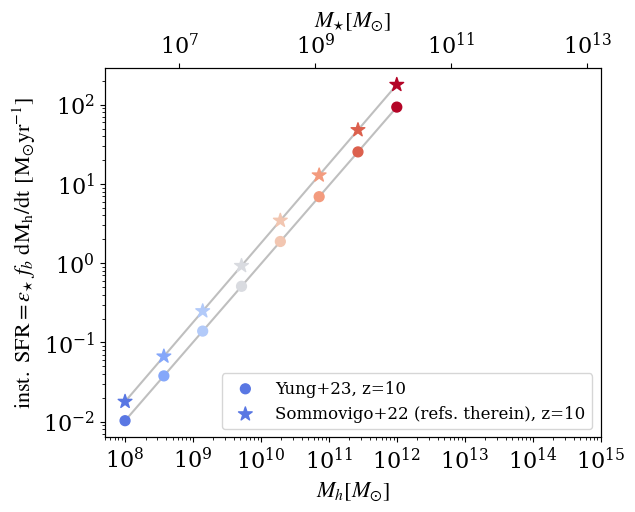

In [63]:
fig, ax = plt.subplots()

sfr_gureft = star_formation_rate(Mh_array, redshift, epsilon, fb, method="GUREFT")
sfr_ls22 = star_formation_rate(Mh_array, redshift, epsilon, fb, method="LS22")

ax.scatter(
    Mh_array,
    sfr_gureft,
    label="Yung+23, z=" + str(redshift),
    s=50.0,
    marker="o",
    color=custom_colormap(np.linspace(0, 1, len(Mh_array))),
)
ax.scatter(
    Mh_array,
    sfr_ls22,
    label="Sommovigo+22 (refs. therein), z=" + str(redshift),
    s=107.0,
    marker="*",
    color=custom_colormap(np.linspace(0, 1, len(Mh_array))),
)
ax.plot(Mh_array, sfr_gureft, color="grey", alpha=0.5, zorder=-10)
ax.plot(Mh_array, sfr_ls22, color="grey", alpha=0.5, zorder=-10)

ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlim(5e7, 1e15)
ax.legend(fontsize=12)
ax.set_ylabel(r"$\mathrm{inst.\ SFR}= \epsilon_{\star}\ f_b\ \mathrm{dM_h/dt}$ $\mathrm{[M_{\odot} yr^{-1}}]$")
ax.set_xlabel(r"$M_h [M_{\odot}]$")

# Secondary x-axis for M_star
ax2 = ax.twiny()
ax2.set_xlim(5e7 * fb * epsilon, 1e15 * fb * epsilon)
ax2.set_xscale("log")
ax2.set_xlabel(r"$M_{\star} [M_{\odot}]$")

print("\n\n Saving fig0_sfr_vs_mhalo.pdf")
fig.savefig(OUTPUT_DIR / "fig0_sfr_vs_mhalo.pdf", bbox_inches="tight")
plt.show()

## Figure 1: Galaxy Evolution 4-Panel Plot

For each halo mass, build star formation history and compute:
1. **SFR evolution** (top panel)
2. **Stellar mass build-up** (second panel)
3. **Dust mass accumulation** (third panel)
4. **Dust-to-stellar mass ratio** (bottom panel)

Convolve SB99 SSP tables with SFH to get L1500, SN rates, and dust masses.
Results are saved to `Properties_*.txt` files for later analysis.


Considero halo # ---> 0
Stays optically thin up to z=10

Considero halo # ---> 1
Stays optically thin up to z=10

Considero halo # ---> 2
Stays optically thin up to z=10

Considero halo # ---> 3
Stays optically thin up to z=10

Considero halo # ---> 4
time after which given halo is optically thick in the V-band --> 0.95 134.00
Corresponding to z= 10.000000022692342 redshift

Considero halo # ---> 5
time after which given halo is optically thick in the V-band --> 1.00 95.69
Corresponding to z= 10.709958473854751 redshift

Considero halo # ---> 6
time after which given halo is optically thick in the V-band --> 1.00 69.49
Corresponding to z= 11.271829881587108 redshift

Considero halo # ---> 7
time after which given halo is optically thick in the V-band --> 1.01 53.37
Corresponding to z= 11.700453321975067 redshift


 Saving fig1_galaxy_evolution.pdf


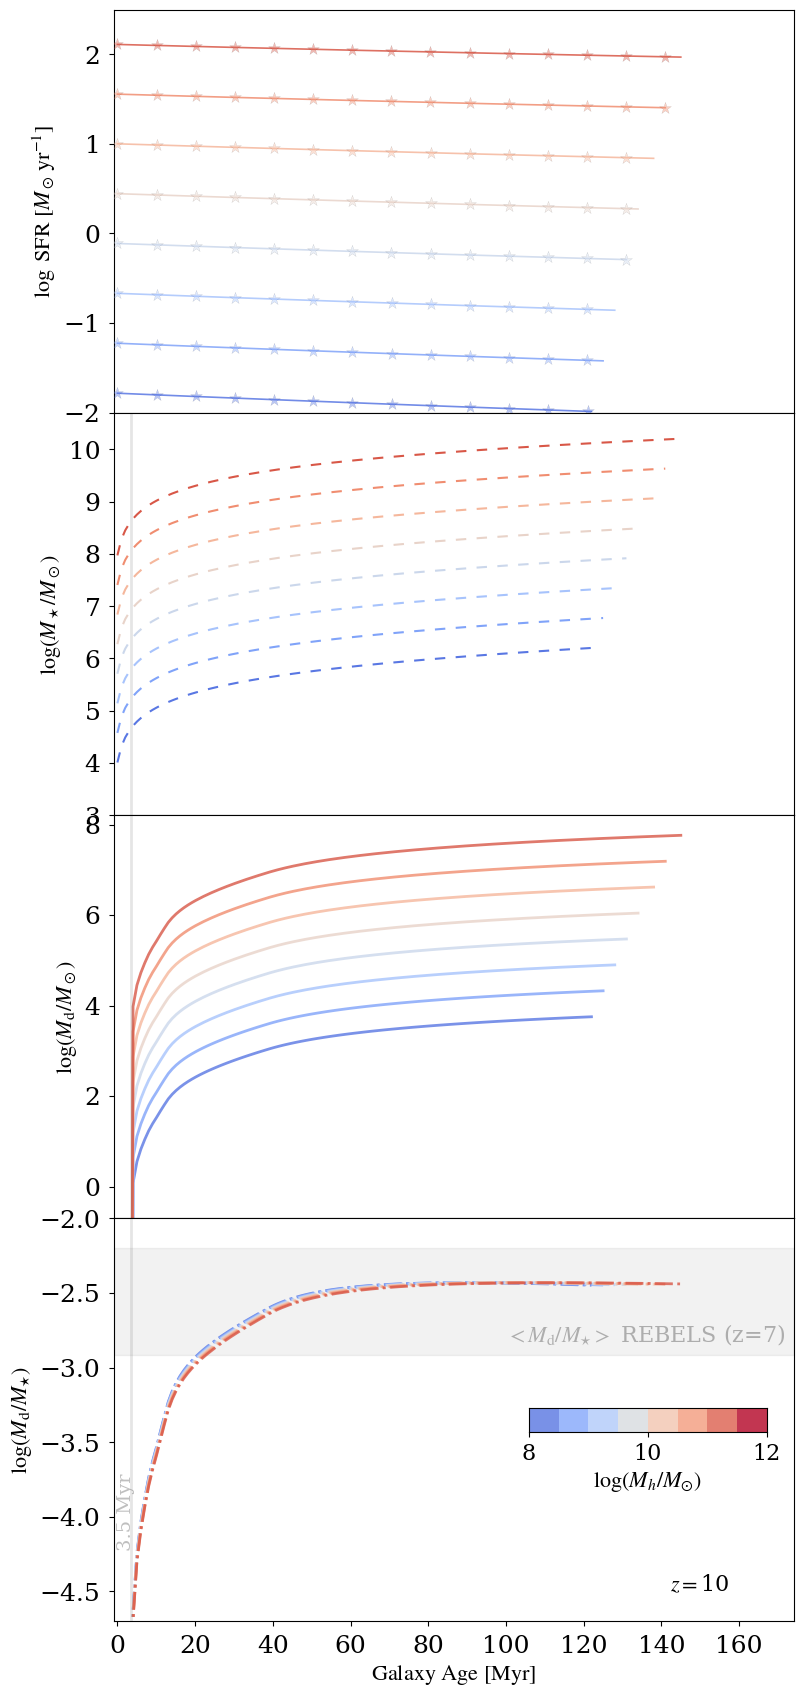

In [64]:
# Generate spin parameter distribution from GUREFT (Yung+23): lognormal
spin_param_distr = np.random.lognormal(mean=-3.6, sigma=0.5677, size=1000)

# Create 4-panel figure
fig, (ax_sfr, ax_mstar, ax_md, ax_ratio) = plt.subplots(4, 1, figsize=(8, 17), sharex=True)

plt.subplots_adjust(left=0.14, bottom=0.045, right=0.99, top=0.993, wspace=0.2, hspace=0.0)

age_ott = []
for j in range(len(Mh_array)):
    col = custom_colormap(float(j) / len(Mh_array))
    print("\nConsidero halo # --->", j)

    sfh, log_mst_build, age = star_formation_history(Mh_array[j], redshift, tstep, epsilon)

    # Compute derived quantities
    l1500_arr = compute_l1500_steps(l1500=l1500_sb99, age=age, tstep=tstep, sfh=sfh, time_yr_l1500=time_yr_l1500)
    n_sn_arr, md_arr = compute_mdust_steps(age, tstep, sfh, time_yr, log_snr_yr, yd)
    dot_nion_arr = compute_dotnion_steps(age, tstep, sfh, time_yr_nion, log_dot_nion)

    # SFR panel: line + sparse star markers
    ax_sfr.plot(age, np.log10(sfh), color=col, lw=1.2, alpha=0.85, zorder=2)
    step = 10
    ax_sfr.scatter(
        age[::step],
        np.log10(sfh)[::step],
        marker="*",
        s=80,
        color=col,
        edgecolor="k",
        linewidth=0.1,
        alpha=0.4,
        zorder=3,
    )
    if j == 0:
        ax_sfr.set_ylabel(r"$\log\ \mathrm{SFR}\ [M_\odot\,\mathrm{yr}^{-1}]$")

    # Mstar panel
    ax_mstar.plot(age, log_mst_build, ls="--", lw=1.5, dashes=[5, 5], color=col)
    if j == 0:
        ax_mstar.set_ylabel(r"$\log (M_\star/M_\odot)$")

    # Md panel
    log_md = np.log10(md_arr)
    ax_md.plot(age, log_md, lw=2.0, alpha=0.8, color=col)
    if j == 0:
        ax_md.set_ylabel(r"$\log (M_{\rm d}/M_\odot)$")

    # Md /Mstar panel
    ratio = log_md - log_mst_build
    ax_ratio.plot(age, ratio, lw=2.0, ls="-.", alpha=0.8, color=col)

    # Calculate tau_V and optically thick transition
    tau_v = optical_depth(kv, md_arr, Mh_array[j], spin_param_distr.mean(), redshift)
    tau_v_max = optical_depth(kv, md_arr, Mh_array[j], np.percentile(spin_param_distr, 16), redshift)
    tau_v_min = optical_depth(kv, md_arr, Mh_array[j], np.percentile(spin_param_distr, 84), redshift)

    if tau_v[-1] >= 0.9:
        print(
            "time after which given halo is optically thick in the V-band --> "
            f"{tau_v[find_nearest(tau_v, 1.0)]:.2f} {age[find_nearest(tau_v, 1.0)]:.2f}",
        )

        # Compute redshift when galaxy was `age_thick` Myr old
        reds_thick = z_at_value(
            cosmo.age,
            (cosmo.age(redshift).value - (age[-1] - age[find_nearest(tau_v, 1.0)]) * const.Myr / const.Gyr)
            * cosmo.age(redshift).unit,
            method="bounded",
        )
        print("Corresponding to z=", reds_thick)
    else:
        print("Stays optically thin up to z=" + str(redshift))
        age_ott = np.append(age_ott, -999)

    # Save outputs
    header_text = (
        f"log(Mhalo/Msun) = {np.log10(Mh_array[j]):.3f}\n"
        f"yd = {yd}, epsilon_star = {epsilon}, spin = {spin_param}\n"
        f"Columns: t[Myr]  SFR[Msun/yr]  log(Mstar/Msun)  log(Md/Msun)  "
        f"tau_v(MW dust)  tau_v_16th  tau_v_84th  L_1500[erg/s]"
    )

    np.savetxt(
        props_path(Mh_array[j], yd, epsilon, spin_param, redshift),
        np.c_[age, sfh, log_mst_build, np.log10(md_arr), tau_v, tau_v_min, tau_v_max, l1500_arr],
        header=header_text,
    )

# Global formatting
for ax in (ax_sfr, ax_mstar, ax_md, ax_ratio):
    ax.tick_params(axis="both", which="major", labelsize=18, pad=6)

ax_sfr.set_ylim(-2, 2.5)
ax_mstar.set_ylim(3, 10.7)
ax_md.set_ylim(-0.7, 8.2)
ax_ratio.set_ylim(-4.7, -2)
ax_ratio.set_xlim(-1, 1.2 * age[-1])

# Labels and reference lines
ax_ratio.set_xlabel(r"$\mathrm{Galaxy\ Age\ [Myr]}$")
ax_ratio.set_ylabel(r"$\log (M_{\rm d}/M_{\star})$")
ax_ratio.text(0.98 * age[-1], -4.5, "$z=$" + str(int(redshift)))

for ax in (ax_mstar, ax_md, ax_ratio):
    ax.axvline(3.5, color="grey", lw=2.0, alpha=0.2)
ax_ratio.text(0.0, -4.2, "3.5 Myr", rotation=90, fontsize=14, color="grey", alpha=0.5)

# REBELS Md/Mstar region
ax_ratio.axhspan(
    np.percentile(rebels["log_Md"] - rebels["log_Mstar"], 16),
    np.percentile(rebels["log_Md"] - rebels["log_Mstar"], 84),
    color="grey",
    alpha=0.1,
)
ax_ratio.text(100, np.log10(0.0015), r"$< M_{\rm d}/M_{\star}>$ REBELS (z=7)", fontsize=16, color="grey", alpha=0.6)

# Colorbar
bar = np.zeros((1, len(Mh_array)))
bar[0][:] = np.linspace(np.log10(Mh_array).min(), np.log10(Mh_array).max(), len(Mh_array))
cbaxis = inset_axes(ax_ratio, width="35%", height="6%", loc="center right", borderpad=1.2)
ext = (np.log10(Mh_array).min(), np.log10(Mh_array).max(), 0.0, 0.8)
cbaxis.imshow(
    bar,
    cmap=custom_colormap,
    extent=ext,
    aspect="auto",
    vmin=np.log10(Mh_array).min(),
    vmax=np.log10(Mh_array).max(),
    alpha=0.8,
)
cbaxis.set_xlabel(r"$\log (M_{h}/M_{\odot})$")
cbaxis.tick_params(axis="both", which="major", pad=4)
cbaxis.set_yticks([])

print("\n\n Saving fig1_galaxy_evolution.pdf")
fig.savefig(OUTPUT_DIR / "fig1_galaxy_evolution.pdf", bbox_inches="tight")
plt.show()

## Figure 2: Intrinsic M_UV vs M_star Relation

Plot the intrinsic (no dust attenuation) absolute UV magnitude versus stellar mass.
Read L1500 values from saved Properties files and convert to M_UV. Compare with observations.

LUV [erg/s/Angstrom] --> 2.518e+26
LUV [erg/s/Angstrom] --> 9.252e+26
LUV [erg/s/Angstrom] --> 3.399e+27
LUV [erg/s/Angstrom] --> 1.248e+28
LUV [erg/s/Angstrom] --> 4.583e+28
LUV [erg/s/Angstrom] --> 1.684e+29
LUV [erg/s/Angstrom] --> 6.181e+29
LUV [erg/s/Angstrom] --> 2.270e+30


 Saving fig2_muv_vs_mstar_intrinsic.pdf


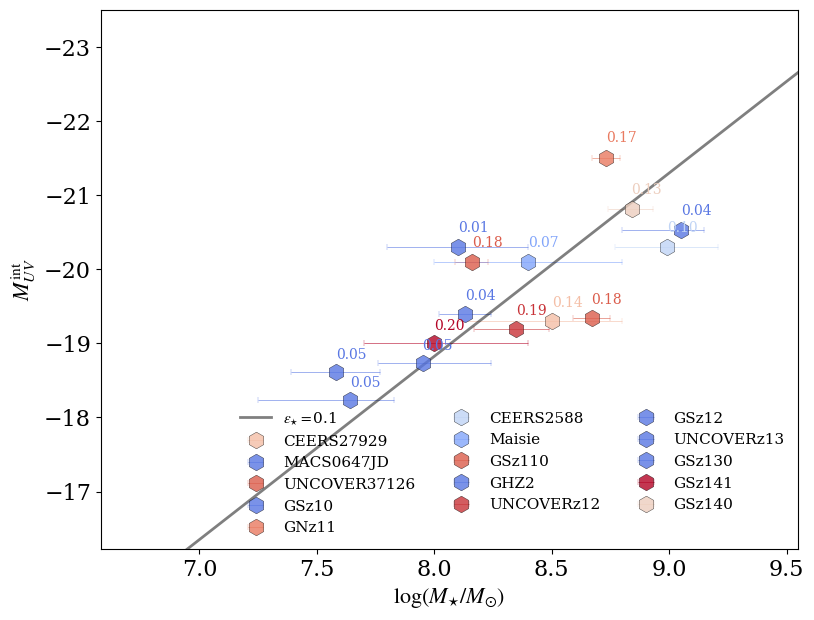

[logMstar, MUV] for epsilon= 0.1 --> [ 6.19904499  6.77047357  7.34190214  7.91333071  8.48475928  9.05618785
  9.62761642 10.19904499] [-14.37272757 -15.7855886  -17.19822128 -18.61063896 -20.0228387
 -21.43595576 -22.84766122 -24.26013001]


In [68]:
fig, ax = plt.subplots(figsize=(9, 7))

LUV_z10 = []
for j in range(len(Mh_array)):
    _props_path = props_path(Mh_array[j], yd, epsilon, spin_param, redshift)

    luv_last = np.loadtxt(_props_path, usecols=7)[-1]
    LUV_z10.append(luv_last)
    print(f"LUV [erg/s/Angstrom] --> {luv_last:.3e}")

LUV_z10 = np.asarray(LUV_z10)

# Plot observational data
if redshift >= 10:
    jwst_plot = jwst[
        (jwst["log_Mstar"] > 0)
        & np.isfinite(jwst["MUV"])
        & np.isfinite(jwst["err_logMstar_low"])
        & np.isfinite(jwst["err_logMstar_high"])
        & np.isfinite(jwst["tau_v"])
    ].copy()

    tau_span = jwst_plot["tau_v"].max() - 0.05
    if not np.isfinite(tau_span) or tau_span <= 0:
        tau_span = 1.0

    for _, row in jwst_plot.iterrows():
        point_color = custom_colormap((row["tau_v"] - 0.05) / tau_span)
        ax.errorbar(
            row["log_Mstar"],
            row["MUV"],
            xerr=[[abs(row["err_logMstar_low"])], [abs(row["err_logMstar_high"])]],
            label=row["name"],
            ms=12.0,
            marker="h",
            capsize=2.5,
            elinewidth=0.5,
            mec="black",
            alpha=0.8,
            mew=0.3,
            ls="none",
            color=point_color,
        )
        if row["tau_v"] > 0:
            ax.text(
                row["log_Mstar"],
                1.01 * row["MUV"],
                f"{row['tau_v']:.2f}",
                fontsize=10,
                color=point_color,
            )

if redshift == 7:
    for _, row in rebels.iterrows():
        ax.errorbar(
            row["log_Mstar"],
            row["MUV"],
            xerr=[[row["err_log_Mstar_low"]], [row["err_log_Mstar_high"]]],
            label="REB-" + str(int(row["id"])),
            ms=12.0,
            marker="s",
            capsize=2.5,
            mec="black",
            elinewidth=0.5,
            alpha=0.8,
            mew=0.3,
            ls="none",
            color=custom_colormap((row["Av"] - 0.05 * 1.086) / (rebels["Av"].max() - 0.05 * 1.086)),
        )

# Plot model prediction
# Extend model line analytically to higher masses (beyond props-file range)
_Mh_ext = np.logspace(np.log10(Mh_array[-1]), 13, 6)[1:]  # skip overlap point
_LUV_ext = []
for _mh in _Mh_ext:
    _sfh, _, _age = star_formation_history(_mh, redshift, tstep, epsilon)
    _l1500 = compute_l1500_steps(l1500=l1500_sb99, age=_age, tstep=tstep, sfh=_sfh,
                                  time_yr_l1500=time_yr_l1500, method="SB99")
    _LUV_ext.append(_l1500[-1])
_Mstar_plot2 = halo_to_stellar_mass(np.concatenate([Mh_array, _Mh_ext]), fb, epsilon)
_LUV_plot2 = np.concatenate([LUV_z10, _LUV_ext])

ax.plot(
    np.log10(_Mstar_plot2),
    l1500_to_muv_conv(_LUV_plot2),
    ms=8.0,
    alpha=0.5,
    label="$\\epsilon_{\\star}=$" + str(epsilon),
    color="black",
    lw=2.0,
)

ax.set_ylabel("$M_{UV}^{\\rm int}$")
ax.set_xlabel("$\\log (M_{\\star}/M_{\\odot})$")
ax.legend(fontsize=11, loc="lower right", ncols=3, frameon=False)
if redshift >= 10:
    _obs_muv2 = jwst_plot["MUV"].dropna().values
elif redshift == 7:
    _obs_muv2 = rebels["MUV"].dropna().values
else:
    _obs_muv2 = l1500_to_muv_conv(LUV_z10)
_muv_model2 = l1500_to_muv_conv(_LUV_plot2)
ax.set_ylim(np.nanmax(_obs_muv2) + 2, max(np.nanmin(_obs_muv2) - 2, -24))
if redshift >= 10:
    _obs_ms2 = jwst_plot["log_Mstar"].dropna().values
elif redshift == 7:
    _obs_ms2 = rebels["log_Mstar"].dropna().values
else:
    _obs_ms2 = np.log10(Mstar_array)
ax.set_xlim(_obs_ms2.min() - 1., _obs_ms2.max() + 0.5)
print("\n\n Saving fig2_muv_vs_mstar_intrinsic.pdf")
fig.savefig(OUTPUT_DIR / "fig2_muv_vs_mstar_intrinsic.pdf", bbox_inches="tight")
plt.show()

print("[logMstar, MUV] for epsilon=", str(epsilon), "-->", str(np.log10(Mstar_array)), str(l1500_to_muv_conv(LUV_z10)))

## Figure 3: Optical Depth τ_V Build-up vs Galaxy Age

Plot V-band optical depth evolution for each halo mass. Show scatter from spin parameter
uncertainty as shaded regions. Overlay JWST (z≥10) or REBELS (z=7) observational data.


==== κ_abs(1500 Å) results ====
MW WD01 dust (ext)     : 71794.01921211 cm^2 g^-1
Stellar dust model (ext): 8077.94524315 cm^2 g^-1
WD01 dust (abs)     : [33721.33239661] cm^2 g^-1
Stellar dust model (abs): [4050.6206372] cm^2 g^-1



 Saving fig3_kappa_lambda.pdf


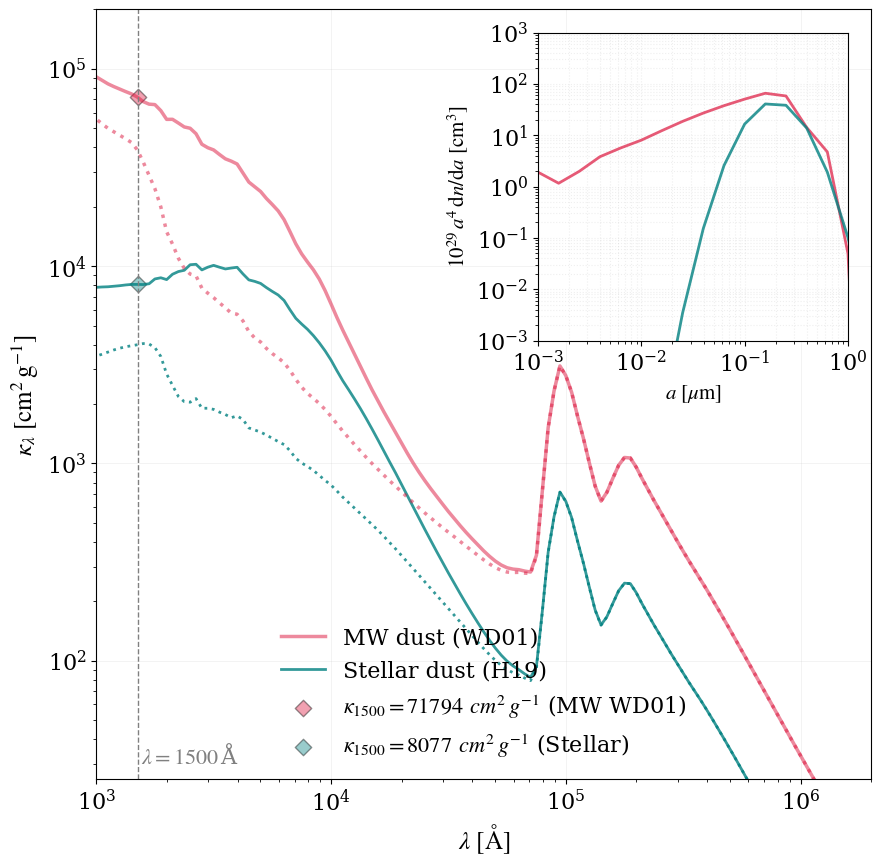

In [69]:
# ==========================================================
# Compare MW WD01 vs stellar dust: κ_λ + a^4 dn/da inset
# ==========================================================

fig, ax = plt.subplots(figsize=(10, 10))

# --- MAIN PANEL: κ_ext(λ) ---
ax.plot(wavelengths, kappa_ext_tot, lw=2.5, alpha=0.5, color="crimson", label="MW dust (WD01)")
ax.plot(wavelengths, kappa_ext_star_tot, lw=2.0, alpha=0.8, color="teal", label="Stellar dust (H19)")
# -- abs
ax.plot(wavelengths, kappa_abs_tot, lw=2.5, alpha=0.5, color="crimson", ls=":")
ax.plot(wavelengths, kappa_abs_star_tot, lw=2.0, alpha=0.8, color="teal", ls=":")


print("\n==== κ_abs(1500 Å) results ====")
print(f"MW WD01 dust (ext)     : {kuv_drn} cm^2 g^-1")
print(f"Stellar dust model (ext): {kuv_hir} cm^2 g^-1")
print(f"WD01 dust (abs)     : {kappa_abs_tot[wavelengths == 1.585e3]} cm^2 g^-1")
print(f"Stellar dust model (abs): {kappa_abs_star_tot[wavelengths == 1.585e3]} cm^2 g^-1")
print("================================\n")

# --- Plot Points at 1500 Å ---
ax.scatter(
    1500,
    kuv_drn,
    color="crimson",
    edgecolor="black",
    s=70,
    marker="D",
    alpha=0.4,
    label=rf"$\kappa_{{1500}}={int(kuv_drn)}$ $cm^2\,g^{{-1}}$ (MW WD01)",
)

ax.scatter(
    1500,
    kuv_hir,
    color="teal",
    edgecolor="black",
    s=70,
    marker="D",
    alpha=0.4,
    label=rf"$\kappa_{{1500}}={int(kuv_hir)}$ $cm^2\,g^{{-1}}$ (Stellar)",
)

# vertical line at 1500 Å
ax.axvline(1500.0, color="gray", linestyle="--", lw=1)


ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(25, 2e5)
ax.set_xlim(1e3, 2e6)  # 1000 Å – 200 µm

ax.text(1550.0, ax.get_ylim()[0] * 1.2, r"$\lambda=1500\,$Å", fontsize=16, color="gray")


ax.set_xlabel(r"$\lambda\ [\mathrm{\AA}]$", fontsize=18)
ax.set_ylabel(r"$\kappa_{\lambda}\ [{\rm cm}^2\,{\rm g}^{-1}]$", fontsize=18)
ax.tick_params(axis="both", which="major", labelsize=16)
ax.grid(True, alpha=0.2, lw=0.5)
ax.legend(frameon=False, fontsize=16, loc="lower center")

# ==========================================================
# INSET: 1e29 * a^4 dn/da for WD01 vs stellar dust
# ==========================================================
inset_ax = ax.inset_axes([0.57, 0.57, 0.4, 0.4])

# build a common size grid (cm) for total (C+Si)

a_all = np.sort(np.unique(np.concatenate([radius_graphite, radius_silicate])))

# interpolate WD01 dn/da (per H) onto common grid
dn_da_wd = np.interp(a_all, radius_graphite, graphite_dist, left=0.0, right=0.0)
dn_da_wd += np.interp(a_all, radius_silicate, silicate_dist, left=0.0, right=0.0)
# interpolate stellar dn/da onto same grid
dn_da_star = np.interp(a_all, radius_graphite, graphite_dist_star, left=0.0, right=0.0)
dn_da_star += np.interp(a_all, radius_silicate, silicate_dist_star, left=0.0, right=0.0)

# quantity to plot: 1e29 * a^4 dn/da   [cm^3]
y_wd = 1e29 * a_all**4 * dn_da_wd
y_star = 1e29 * a_all**4 * dn_da_star

# convert a to µm for x–axis
inset_ax.loglog(a_all * 1e4, y_wd, color="crimson", alpha=0.7, lw=2, label="MW dust")
inset_ax.loglog(a_all * 1e4, y_star, color="teal", alpha=0.8, lw=2, label="Stellar dust (H19)")

inset_ax.set_xscale("log")
inset_ax.set_yscale("log")
inset_ax.set_xlim(1e-3, 1.0)
# pick a sensible y–range; can tweak after first run
inset_ax.set_ylim(1e-3, 1e3)

inset_ax.set_xlabel(r"$a\ [\mu{\rm m}]$", fontsize=15)
inset_ax.set_ylabel(r"$10^{29}\,a^4\,{\rm d}n/{\rm d}a\ [{\rm cm}^3]$", fontsize=15)
inset_ax.grid(True, which="both", ls=":", alpha=0.2)

print("\n\n Saving fig3_kappa_lambda.pdf")
fig.savefig(OUTPUT_DIR / "fig3_kappa_lambda.pdf", bbox_inches="tight")
plt.show()


log(mh/Msol)= 8.000
log(Mstar/Msol)= 6.199
log(Md/Msol)= 0.574
rd/kpc --> 0.191 - 0.099 + 0.096

log(mh/Msol)= 8.571
log(Mstar/Msol)= 6.770
log(Md/Msol)= 0.636
rd/kpc --> 0.296 - 0.154 + 0.149

log(mh/Msol)= 9.143
log(Mstar/Msol)= 7.342
log(Md/Msol)= 0.690
rd/kpc --> 0.459 - 0.239 + 0.231

log(mh/Msol)= 9.714
log(Mstar/Msol)= 7.913
log(Md/Msol)= 0.738
rd/kpc --> 0.712 - 0.370 + 0.358

log(mh/Msol)= 10.286
log(Mstar/Msol)= 8.485
log(Md/Msol)= 0.781
rd/kpc --> 1.104 - 0.574 + 0.555

log(mh/Msol)= 10.857
log(Mstar/Msol)= 9.056
log(Md/Msol)= 0.821
rd/kpc --> 1.711 - 0.889 + 0.861

log(mh/Msol)= 11.429
log(Mstar/Msol)= 9.628
log(Md/Msol)= 0.857
rd/kpc --> 2.653 - 1.379 + 1.335

log(mh/Msol)= 12.000
log(Mstar/Msol)= 10.199
log(Md/Msol)= 0.890
rd/kpc --> 4.114 - 2.138 + 2.070


 Saving fig3_tau_v_buildup.pdf


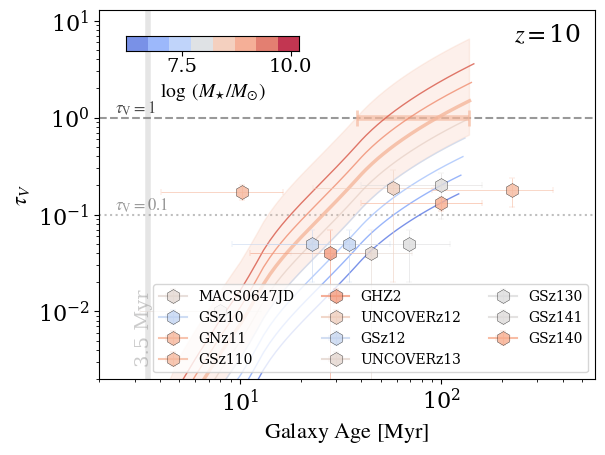

In [74]:
fig, ax = plt.subplots()

for j in range(len(Mh_array)):
    col = custom_colormap(float(j) / len(Mh_array))
    print(f"\nlog(mh/Msol)= {np.log10(Mh_array[j]):.3f}")
    print(f"log(Mstar/Msol)= {np.log10(Mstar_array[j]):.3f}")

    _props_path = props_path(Mh_array[j], yd, epsilon, spin_param, redshift)

    print(f"log(Md/Msol)= {np.log10(np.loadtxt(_props_path, usecols=3)[-1]):.3f}")
    rd_mean = disk_scale_length(redshift, Mh_array[j], spin_param_distr.mean())
    rd_lo = disk_scale_length(redshift, Mh_array[j], np.percentile(spin_param_distr, 16))
    rd_hi = disk_scale_length(redshift, Mh_array[j], np.percentile(spin_param_distr, 84))
    print(f"rd/kpc --> {rd_mean:.3f} - {rd_mean - rd_lo:.3f} + {rd_hi - rd_mean:.3f}")

    # Load saved properties (all columns at once)
    _props_data = np.loadtxt(_props_path)
    time_arr = _props_data[:, 0]
    tau_v_arr = _props_data[:, 4]
    tau_v_min_arr = _props_data[:, 5]
    tau_v_max_arr = _props_data[:, 6]

    lw = 1.0

    # Highlight fiducial halo
    if j == 5:
        ax.fill_between(time_arr, tau_v_min_arr, tau_v_max_arr, color=col, alpha=0.2)
        ax.errorbar(
            time_arr[find_nearest(tau_v_arr, 1.0)],
            1.0,
            xerr=[
                [-time_arr[find_nearest(tau_v_max_arr, 1.0)] + time_arr[find_nearest(tau_v_arr, 1.0)]],
                [time_arr[find_nearest(tau_v_min_arr, 1.0)] - time_arr[find_nearest(tau_v_arr, 1.0)]],
            ],
            capsize=6,
            lw=4.0,
            color=col,
            alpha=0.65,
            capthick=2.0,
            ls=":",
        )
        lw = 2.5

    ax.plot(time_arr, tau_v_arr, color=col, linewidth=lw, alpha=0.8)

# Reference lines
ax.axhline(0.1, ls=":", color="black", alpha=0.25, zorder=-1000)
ax.text(2.4, 0.11, "$\\tau_{\\rm V}=0.1$", color="black", alpha=0.4, fontsize=12)
ax.axhline(1.0, ls="--", color="black", alpha=0.4, zorder=-1000)
ax.text(2.4, 1.1, "$\\tau_{\\rm V}=1$", color="black", alpha=0.7, fontsize=12)
ax.plot(3.5 * np.ones(10), np.linspace(1e-29, 80, 10), color="grey", lw=4.0, alpha=0.2, zorder=-1000)
ax.text(3.0, 3e-3, "3.5 Myr", rotation=90, fontsize=14, color="grey", alpha=0.4)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(2e-3, 13)
ax.set_xlim(2, 4 * time_arr.max())
ax.set_ylabel("$\\tau_V$")
ax.set_xlabel("$\\mathrm{Galaxy\\ Age\\ [Myr]}$")

# Colorbar for Mstar
bar = np.zeros((1, len(Mstar_array)))
bar[0][:] = np.linspace(np.log10(Mstar_array).min(), np.log10(Mstar_array).max(), len(Mstar_array))
cbaxis = inset_axes(ax, width="35%", height="4%", loc="upper left", borderpad=1.2)
ext = (np.log10(Mstar_array).min(), np.log10(Mstar_array).max(), 0.0, 0.8)
cbaxis.imshow(
    bar,
    cmap=custom_colormap,
    extent=ext,
    aspect="auto",
    vmin=np.log10(Mstar_array).min(),
    vmax=np.log10(Mstar_array).max(),
    alpha=0.8,
)
cbaxis.set_xlabel("$\\log\\ (M_{\\star}/M_{\\odot})$", fontsize=14)
cbaxis.tick_params(axis="both", which="major", labelsize=14, pad=1)
cbaxis.set_yticks([])

# Plot observational data
if redshift >= 10:
    for jj, row in jwst.iterrows():
        if row["tau_v"] > 0 and row["log_Mstar"] > 0 and row["age"] > 0:
            err_low = row["err_tau_low"]
            if err_low >= row["tau_v"] or np.isnan(err_low):
                uplim = True
                err_low = 0.1 * row["tau_v"]
            else:
                uplim = False
            ax.errorbar(
                row["age"],
                row["tau_v"],
                yerr=[[np.abs(row["err_tau_up"])], [np.abs(err_low)]],
                xerr=[[0.6 * row["age"]], [0.6 * row["age"]]],
                ms=10.0,
                marker="h",
                capsize=2.5,
                mec="black",
                elinewidth=0.5,
                alpha=0.8,
                color=custom_colormap(
                    (row["log_Mstar"] - np.log10(Mstar_array).min())
                    / (np.log10(Mstar_array).max() - np.log10(Mstar_array).min())
                ),
                label=row["name"],
                mew=0.3,
                uplims=uplim,
            )

if redshift == 7:
    for _, row in rebels.iterrows():
        ax.errorbar(
            row["age_Gyr"],
            row["Av"] / 1.086,
            yerr=[[row["err_Av_low"]], [row["err_Av_high"]]],
            xerr=[[row["err_age_low_Gyr"]], [row["err_age_high_Gyr"]]],
            ms=10.0,
            marker="s",
            capsize=2.5,
            mec="black",
            elinewidth=0.5,
            alpha=0.8,
            color=custom_colormap(
                (row["log_Mstar"] - np.log10(Mstar_array).min())
                / (np.log10(Mstar_array).max() - np.log10(Mstar_array).min())
            ),
            mew=0.3,
        )

ax.text(0.97, 0.93, "$z=$" + str(int(redshift)), fontsize=18, transform=ax.transAxes, ha="right", va="center")
ax.legend(frameon=True, ncols=3, fontsize=10)
print("\n\n Saving fig3_tau_v_buildup.pdf")
fig.savefig(OUTPUT_DIR / "fig3_tau_v_buildup.pdf", bbox_inches="tight")
plt.show()

### Figure -:  Transmission Functions for Dust Geometries

Quick plot comparing transmission functions T(τ) for different dust geometries.



 Saving fig_transmission_geometries.pdf


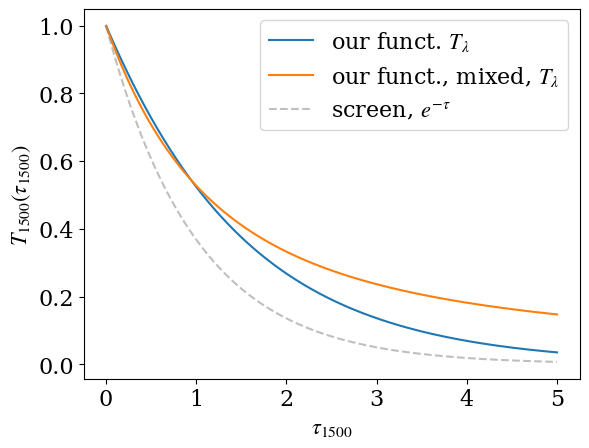

In [75]:
fig, ax = plt.subplots()
tau_grid = np.linspace(1e-3, 5, 1000)

ax.plot(
    tau_grid,
    transmission_sphere(tau_grid),
    label=r"our funct. $T_{\lambda}$",
)
ax.plot(
    tau_grid,
    transmission_sphere_mixed(tau_grid),
    label=r"our funct., mixed, $T_{\lambda}$",
)
ax.plot(
    tau_grid,
    np.exp(-tau_grid),
    ls="--",
    color="grey",
    alpha=0.5,
    label=r"screen, $e^{-\tau}$",
)
ax.set_ylabel(r"$T_{1500}(\tau_{1500})$")
ax.set_xlabel(r"$\tau_{1500}$")
ax.legend()
print("\n\n Saving fig_transmission_geometries.pdf")
fig.savefig(OUTPUT_DIR / "fig_transmission_geometries.pdf", bbox_inches="tight")
plt.show()

## Figure 4:

In [76]:
# --- Setup for attenuation curve plots ---

# g_λ — scatter-weighted asymmetry parameter (ascending-wavelength order, matching pivot)
_wl_asc = np.sort(dust_graphite["wavelength"].unique())  # µm, ascending
_radii_c_um = dust_graphite["radius"].unique()  # already sorted ascending
_radii_s_um = dust_silicate["radius"].unique()
_Qsca_c_2d = dust_graphite.pivot(index="radius", columns="wavelength", values="Q_sca").values
_g_c_2d = dust_graphite.pivot(index="radius", columns="wavelength", values="g").values
_Qsca_s_2d = dust_silicate.pivot(index="radius", columns="wavelength", values="Q_sca").values
_g_s_2d = dust_silicate.pivot(index="radius", columns="wavelength", values="g").values

_g_c = compute_g_lambda(_radii_c_um, _Qsca_c_2d, _g_c_2d, graphite_dist)
_g_s = compute_g_lambda(_radii_s_um, _Qsca_s_2d, _g_s_2d, silicate_dist)

# kappa_c_sca / kappa_s_sca are in ascending-wavelength order (from pivot, no reversal)
_w_c = (1.0 / 11.0) * kappa_c_sca
_w_s = (10.0 / 11.0) * kappa_s_sca
g_tot = (_g_c * _w_c + _g_s * _w_s) / (_w_c + _w_s)

# g_λ for stellar dust (same pivot tables, stellar GSD weights)
_g_c_star = compute_g_lambda(_radii_c_um, _Qsca_c_2d, _g_c_2d, graphite_dist_star)
_g_s_star = compute_g_lambda(_radii_s_um, _Qsca_s_2d, _g_s_2d, silicate_dist_star)
_w_c_star = (1.0 / 11.0) * kappa_c_sca_star
_w_s_star = (10.0 / 11.0) * kappa_s_sca_star
g_tot_star = (_g_c_star * _w_c_star + _g_s_star * _w_s_star) / (_w_c_star + _w_s_star)

# Update dust_constants.txt with omega_1500 and g_1500 (require g_tot computed above).
# _wl_asc is in µm; convert to Å for interpolation.
_wl_asc_A = _wl_asc * 1e4
save_dust_constants(
    {
        "kUV_drn":       kuv_drn,
        "kUV_drn_abs":   kuv_drn_abs,
        "kv_drn":        kv_drn,
        "kIR_drn":       kir_drn,
        "omega_1500_drn": float(np.interp(1500.0, _wl_asc_A, omega_tot)),
        "g_1500_drn":    float(np.interp(1500.0, _wl_asc_A, g_tot)),
        "kUV_hir":       kuv_hir,
        "kUV_hir_abs":   kuv_hir_abs,
        "kv_hir":        kv_hir,
        "kIR_hir":       kir_hir,
        "omega_1500_hir": float(np.interp(1500.0, _wl_asc_A, omega_star_tot)),
        "g_1500_hir":    float(np.interp(1500.0, _wl_asc_A, g_tot_star)),
    },
    _dust_constants_path,
)
print(f"Dust constants updated with omega_1500 and g_1500 in {_dust_constants_path}")

kappa_ext_star_fig4 = kappa_ext_star_tot
omega_star_fig4 = omega_star_tot


# Wavelength arrays for plotting (ascending, consistent with kappa arrays)
lam_ang = _wl_asc * 1e4  # µm → Å
i_v = np.argmin(np.abs(lam_ang - 5500.0))

Dust constants updated with omega_1500 and g_1500 in /Users/laurasommovigo/Desktop/dust_JWST_highz/data/dust_constants.txt




 Saving fig4_attenuation_curves.pdf


/Users/laurasommovigo/Desktop/dust_JWST_highz/src/dust_jwst_highz/model/dust.py:1041: RuntimeWarning: divide by zero encountered in log10
  return -2.5 * np.log10(t_lam)
/Users/laurasommovigo/Desktop/dust_JWST_highz/src/dust_jwst_highz/model/dust.py:1041: RuntimeWarning: invalid value encountered in log10
  return -2.5 * np.log10(t_lam)


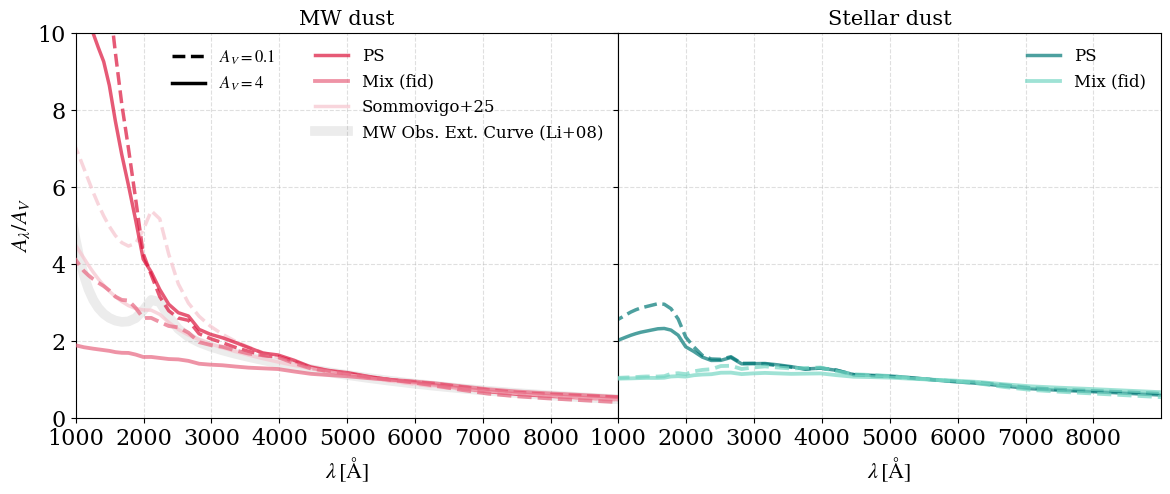

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
plt.subplots_adjust(wspace=0)
ax_mw, ax_stellar = axes


# Helper: Σ_d from desired A_V
def sigmad_from_av(av_target: float, kappa_v: float) -> float:
    """Convert a desired V-band attenuation A_V to dust surface density Σ_d.

    Uses A_V = κ_V · Σ_d · (2.5 / ln 10).

    Parameters
    ----------
    av_target:
        Target V-band attenuation in magnitudes.
    kappa_v:
        V-band dust opacity [cm^2 g^-1].

    Returns
    -------
    float
        Dust surface density Σ_d [g cm^-2].

    """
    # A_V = kappa_v * Σ_d * (2.5 / ln10)
    return av_target / (kappa_v * (2.5 / np.log(10)))


# make shades for different transfer funct., same underlying dust model
def make_shades(base_color: str | tuple) -> list[tuple[float, float, float]]:
    """Return three shades of a base color: darkest, medium, lightest."""
    base = np.array(colors.to_rgb(base_color))
    factors = [1.0, 0.65, 0.25]  # 1.0 = base, <1 = closer to white
    shades = [tuple(1 - f * (1 - base)) for f in factors]
    return shades  # [shade_ps, shade_mix, shade_s24]


# Common A_V values and corresponding line widths
# A_V values, opacity and width
Av_values = [0.15, 4.0]
lw_map = {0.15: 2.5, 4.0: 2.5}
ls_map = {0.15: "--", 4.0: "-"}  # dashed for low A_V, solid for high A_V


def plot_family(
    ax: "plt.Axes",
    kappa_ext_tot: np.ndarray,
    omega_tot: np.ndarray,
    g_tot: np.ndarray,
    color: str,
    title: str,
) -> None:
    """Plot PS, mixed, Sommovigo+24 for A_V = 0.1 and 1.0.

    Uses the given dust model (kappa_ext_tot, omega_tot, g_tot).
    """
    kappa_v = kappa_ext_tot[i_v]

    # generate 3 shades for the 3 transfer functions
    shade_ps, shade_mix, shade_s24 = make_shades(color)

    # Force more separated teals for the stellar panel
    if title == "Stellar dust":
        shade_ps = "#027876"   # darker teal
        shade_mix = "#76d7c4"  # lighter / greener teal
        shade_s24 = "#a7e9df"  # very light (won't be shown anyway on stellar)

    for av in Av_values:
        lw = lw_map[av]

        # Convert desired A_V at V band to Σ_d
        sigmad = sigmad_from_av(av, kappa_v)

        # --- PS (sphere_central) ---
        a_lam_ps = attenuation_curve_rt(
            kappa_ext_tot,
            omega_tot,
            g_tot,
            sigmad,
            geometry="sphere_central",
        )
        a_norm_ps = a_lam_ps / a_lam_ps[i_v]

        # Label only for last A_V value
        label_ps = "PS" if np.isclose(av, Av_values[1]) else None

        ax.plot(lam_ang, a_norm_ps, color=shade_ps, lw=lw, ls=ls_map[av], alpha=0.7, label=label_ps)

        # --- Mixed (sphere_mixed) ---
        a_lam_mix = attenuation_curve_rt(
            kappa_ext_tot,
            omega_tot,
            g_tot,
            sigmad,
            geometry="sphere_mixed",
        )
        a_norm_mix = a_lam_mix / a_lam_mix[i_v]

        label_mix = "Mix (fid)" if np.isclose(av, Av_values[1]) else None

        ax.plot(
            lam_ang, a_norm_mix, color=shade_mix, lw=1.1 * lw, ls=ls_map[av], alpha=0.7, label=label_mix, zorder=1000
        )

        # --- Sommovigo+24 model ---
        # attenuation_curve_sommovigo25 returns A_lambda/A_V for a given A_V
        # Use lam_ang (ascending) converted to µm — lam_um is descending and would mirror the curve
        a_norm_s24 = attenuation_curve_sommovigo25(lam_ang * 1e-4, av)

        label_s24 = "Sommovigo+25" if np.isclose(av, Av_values[1]) else None

        if title == "MW dust":
            ax.plot(lam_ang, a_norm_s24, color=shade_s24, lw=lw, ls=ls_map[av], alpha=0.7, label=label_s24)

    # Cosmetics per panel
    ax.set_title(title, fontsize=15)
    ax.set_xlabel(r"$\lambda\,[\mathrm{\AA}]$", fontsize=16)
    ax.grid(alpha=0.4, ls="--")


# ====== Actual plotting ======
# ===== LEFT PANEL: MW dust (crimson) =====
plot_family(ax=ax_mw, kappa_ext_tot=kappa_ext_tot, omega_tot=omega_tot, g_tot=g_tot, color="crimson", title="MW dust")

# MW extinction curve for reference (only on MW panel)
ax_mw.plot(
    lam_ang,
    attenuation_curve_li08(1e-4 * lam_ang, 0.0, 0.0, 0.0, 0.0, "MW"),
    color="gray",
    lw=7,
    label="MW Obs. Ext. Curve (Li+08)",
    alpha=0.15,
    zorder=-10000,
)

# ===== RIGHT PANEL: Stellar dust (teal) =====
plot_family(
    ax=ax_stellar,
    kappa_ext_tot=kappa_ext_star_fig4,
    omega_tot=omega_star_fig4,
    g_tot=g_tot_star,
    color="teal",
    title="Stellar dust",
)

# ===== Common cosmetics =====
for ax in axes:
    # Mark 1500 Å and V band
    # ax.axvline(lam_UV, color='royalblue', linestyle='--', lw=1.5, alpha=0.6)
    # ax.axvline(lam_V,  color='royalblue', linestyle=':',  lw=1.5, alpha=0.6)
    # ax.text(lam_UV * 1.05, 0.5, r'$1500\,$Å', color='royalblue', fontsize=11)
    # ax.text(lam_V * 1.02,  0.5, r'$V$',       color='royalblue', fontsize=11)

    # ax.set_xticks([2175., 4450., 6580., 9000., 10200., 12200., 16300., 21900.])
    ax.set_xlim(1e3, 8990)

axes[0].set_ylabel(r"$A_{\lambda}/A_V$", fontsize=16)
axes[0].set_ylim(0, 10)

# ---- Legend 1: line styles = A_V (black lines) ----
av_handles = [
    Line2D([0], [0], color="k", lw=2.5, ls=ls_map[av], label=f"$A_V={round(av, 1):g}$")
    for av in Av_values
]
leg_av = ax_mw.legend(handles=av_handles, loc="upper left", bbox_to_anchor=(0.15, 1.0),
                      fontsize=12, frameon=False, ncol=1)

# ---- Legend 2: model legend (colored, unique labels only) ----
handles_mw, labels_mw = ax_mw.get_legend_handles_labels()
seen = set()
model_handles_mw, model_labels_mw = [], []
for h, lab in zip(handles_mw, labels_mw):
    if lab and lab not in seen:
        seen.add(lab)
        model_handles_mw.append(h)
        model_labels_mw.append(lab)

leg_models_mw = ax_mw.legend(model_handles_mw, model_labels_mw,
                              loc="upper right", fontsize=12, frameon=False)
ax_mw.add_artist(leg_av)  # restore A_V legend on top

# Stellar panel: only PS and Mix (unique labels)
handles_st, labels_st = ax_stellar.get_legend_handles_labels()
seen = set()
model_handles_st, model_labels_st = [], []
for h, lab in zip(handles_st, labels_st):
    if lab and lab not in seen:
        seen.add(lab)
        model_handles_st.append(h)
        model_labels_st.append(lab)
ax_stellar.legend(model_handles_st, model_labels_st, loc="upper right", fontsize=12, frameon=False)

print("\n\n Saving fig4_attenuation_curves.pdf")
fig.savefig(OUTPUT_DIR / "fig4_attenuation_curves.pdf", bbox_inches="tight")
plt.show()

## Figure 5: M_UV-M_star with Dust Attenuation

Explore dust attenuation effects for various (ε, y_d) combinations. For each halo:
- Draw 1000 spin parameter realizations from lognormal distribution
- Create spread in τ_UV and attenuated magnitude
- Compare two dust geometries:
  - **Mixed sphere** (T_sphere_mixed)
  - **Central point source** (T_sphere_central)
- Show 16th-84th percentile bands from spin parameter scatter

/Users/laurasommovigo/Desktop/dust_JWST_highz/src/dust_jwst_highz/model/dust.py:830: RuntimeWarning: overflow encountered in exp
  transmission = 2.0 / ((1.0 + eta) * np.exp(psi * tau) + (1.0 - eta) * np.exp(-psi * tau))
/Users/laurasommovigo/Desktop/dust_JWST_highz/src/dust_jwst_highz/model/luminosity.py:48: RuntimeWarning: divide by zero encountered in log10
  return -2.5 * np.log10(l_1500_nu) + 51.63




 Saving fig5_muv_vs_mstar_attenuated.pdf


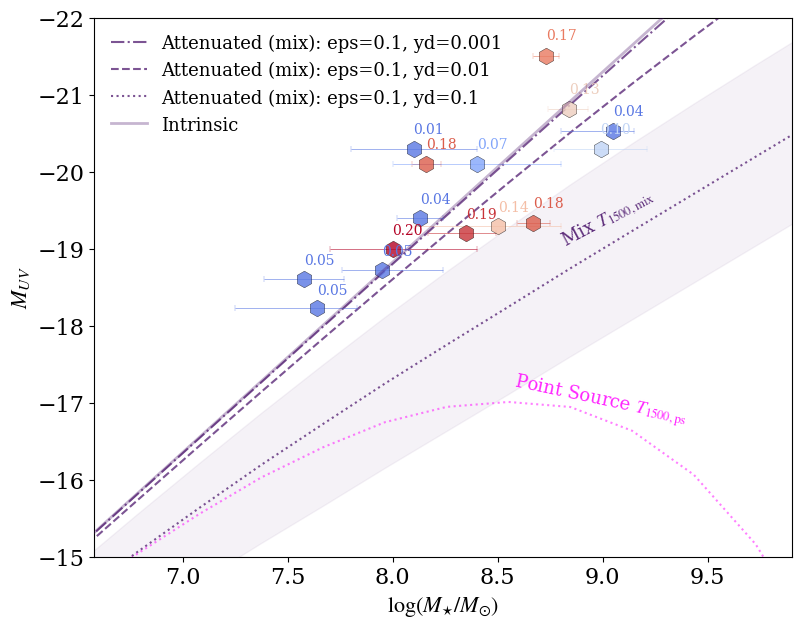

In [85]:
arr_e = np.array([0.1])
arr_yd = np.array([0.001, 0.01, 0.1])
fig, ax = plt.subplots(figsize=(9, 7))

point_colormap = custom_colormap
line_colormap = truncate_colormap(plt.cm.inferno, 0.0, 0.7)

_Mh_fig5 = np.logspace(8, 13, 18)  # extended halo mass range for fig5 model curves

for eps in arr_e:
    Mstar_array = halo_to_stellar_mass(_Mh_fig5, fb, eps)
    spin_param_distr = np.random.lognormal(mean=-3.6, sigma=0.5677, size=1000)

    # Intrinsic track depends on SFH only (not on dust yield).
    muv_intr_array = []

    for yd in arr_yd:
        # Linestyle encodes dust yield
        if yd == 0.1:
            ls = ":"
        elif yd == 0.001:
            ls = "-."
        else:
            ls = "--"

        muv_att_mix, muv_att_mix_u, muv_att_mix_l = [], [], []
        muv_att_ps, muv_att_ps_u, muv_att_ps_l = [], [], []

        for j in range(len(_Mh_fig5)):
            sfh, log_mst_build, age = star_formation_history(_Mh_fig5[j], redshift, tstep, eps)
            l1500_arr = compute_l1500_steps(
                l1500=l1500_sb99,
                age=age,
                tstep=tstep,
                sfh=sfh,
                time_yr_l1500=time_yr_l1500,
                method="SB99",
            )
            n_sn_arr, md_arr = compute_mdust_steps(age, tstep, sfh, time_yr, log_snr_yr, yd)

            # Dust attenuation distribution from spin scatter.
            tau_uv = optical_depth(kuv, md_arr[-1], _Mh_fig5[j], spin_param_distr, redshift)

            # Mixed geometry
            t1500_mix = transmission_sphere_mixed(tau_uv)
            luv_mix_arr = np.atleast_1d(np.asarray(t1500_mix) * l1500_arr[-1])
            muv_mix_dist = l1500_to_muv_conv(luv_mix_arr)
            muv_att_mix.append(np.median(muv_mix_dist))
            muv_att_mix_u.append(np.percentile(muv_mix_dist, 16))
            muv_att_mix_l.append(np.percentile(muv_mix_dist, 84))

            # Point-source geometry
            t1500_ps = transmission_sphere(tau_uv)
            luv_ps_arr = np.atleast_1d(np.asarray(t1500_ps) * l1500_arr[-1])
            muv_ps_dist = l1500_to_muv_conv(luv_ps_arr)
            muv_att_ps.append(np.median(muv_ps_dist))
            muv_att_ps_u.append(np.percentile(muv_ps_dist, 16))
            muv_att_ps_l.append(np.percentile(muv_ps_dist, 84))

            if yd == arr_yd[0]:
                muv_intr_array.append(l1500_to_muv_conv(l1500_arr[-1]))

        line_color = line_colormap(np.clip(eps + eps / 0.05 / 10, 0, 1))

        # Plot mixed geometry
        ax.plot(
            np.log10(Mstar_array),
            muv_att_mix,
            ls=ls,
            lw=1.5,
            label=f"Attenuated (mix): eps={eps}, yd={yd}",
            color=line_color,
            alpha=0.7,
        )

        if yd == arr_yd[-1]:
            ax.fill_between(np.log10(Mstar_array), muv_att_mix_l, muv_att_mix_u, color=line_color, alpha=0.05)
            ax.plot(np.log10(Mstar_array), muv_att_ps, ls=ls, lw=1.5, color="magenta", alpha=0.5)

    # Plot intrinsic
    ax.plot(np.log10(Mstar_array), muv_intr_array, color=line_color, alpha=0.3, label="Intrinsic", lw=2.0, zorder=1000)

ax.legend(loc="upper left", fontsize=13, frameon=False)

# Observational points
if redshift >= 10:
    jwst_plot = jwst[
        (jwst["log_Mstar"] > 0)
        & np.isfinite(jwst["MUV"])
        & np.isfinite(jwst["err_logMstar_low"])
        & np.isfinite(jwst["err_logMstar_high"])
        & np.isfinite(jwst["tau_v"])
    ].copy()

    tau_span = jwst_plot["tau_v"].max() - 0.05
    if not np.isfinite(tau_span) or tau_span <= 0:
        tau_span = 1.0

    for _, row in jwst_plot.iterrows():
        point_color = point_colormap((row["tau_v"] - 0.05) / tau_span)
        ax.errorbar(
            row["log_Mstar"],
            row["MUV"],
            xerr=[[abs(row["err_logMstar_low"])], [abs(row["err_logMstar_high"])]],
            label=row["name"],
            ms=12.0,
            marker="h",
            capsize=2.5,
            mec="black",
            elinewidth=0.5,
            alpha=0.8,
            mew=0.3,
            ls="none",
            color=point_color,
        )
        if row["tau_v"] > 0:
            ax.text(
                row["log_Mstar"],
                1.01 * row["MUV"],
                f"{row['tau_v']:.2f}",
                fontsize=10,
                color=point_color,
            )

if redshift == 7:
    for _, row in rebels.iterrows():
        point_color = point_colormap((row["Av"] - 0.05 * 1.086) / (rebels["Av"].max() - 0.05 * 1.086))
        ax.errorbar(
            row["log_Mstar"],
            row["MUV"],
            xerr=[[row["err_log_Mstar_low"]], [row["err_log_Mstar_high"]]],
            ms=12.0,
            marker="s",
            capsize=2.5,
            elinewidth=0.5,
            mec="black",
            alpha=0.8,
            mew=0.3,
            ls="none",
            color=point_color,
        )

ax.set_xlabel(r"$\log (M_{\star}/M_{\odot})$")
ax.set_ylabel(r"$M_{UV}$")
ax.invert_yaxis()
if redshift >= 10:
    _obs_muv5 = jwst_plot["MUV"].dropna().values
elif redshift == 7:
    _obs_muv5 = rebels["MUV"].dropna().values
else:
    _obs_muv5 = muv_intr_array
if redshift >= 10:
    ax.set_ylim(-15, -22)
else:
    ax.set_ylim(max(np.nanmax(_obs_muv5) + 2, -16), min(np.nanmin(_obs_muv5) - 2, np.nanmin(muv_intr_array) - 1))
if redshift >= 10:
    _obs_ms5 = jwst_plot["log_Mstar"].dropna().values
elif redshift == 7:
    _obs_ms5 = rebels["log_Mstar"].dropna().values
else:
    _obs_ms5 = np.log10(Mstar_array)
if redshift >= 10:
    ax.set_xlim(_obs_ms5.min() - 1, 9.9)
else:
    ax.set_xlim(_obs_ms5.min() - 1, min(_obs_ms5.max() + 2, 11.0))

# Inline geometry labels at log10(Mstar) = 9, inclined along each curve
fig.canvas.draw()
_x_data = np.log10(Mstar_array)
_i9 = np.argmin(np.abs(_x_data - 9.0))
_di = max(2, len(Mstar_array) // 10)
_i1 = max(0, _i9 - _di)
_i2 = min(len(Mstar_array) - 1, _i9 + _di)
for _arr, _col, _lbl, _angle_scale, _offset in [
    (muv_att_mix, line_color, r"Mix $T_{\rm 1500,mix}$", 0.9, 0.3),
    (muv_att_ps, "magenta", r"Point Source $T_{\rm 1500,ps}$", 0.4, 0.55),
]:
    _p1 = ax.transData.transform((_x_data[_i1], _arr[_i1]))
    _p2 = ax.transData.transform((_x_data[_i2], _arr[_i2]))
    _angle = np.degrees(np.arctan2(_p2[1] - _p1[1], _p2[0] - _p1[0])) * _angle_scale
    ax.text(
        9.0, _arr[_i9] - _offset, _lbl,
        color=_col, fontsize=13, ha="center", va="top", alpha=0.85,
        rotation=_angle, rotation_mode="anchor",
    )

print("\n\n Saving fig5_muv_vs_mstar_attenuated.pdf")
fig.savefig(OUTPUT_DIR / "fig5_muv_vs_mstar_attenuated.pdf", bbox_inches="tight")
plt.show()

## Figure 6

In [86]:
# --- Helper to get MUV draws for a given Mach using the clumpy LOS logic ---
def get_muv_clumpy(
    mach: float,
    sigmad_arr: np.ndarray,
    u_seeds_array: np.ndarray,
    n_los: int,
    kappa_uv: float,
    l_intrinsic: float,
) -> np.ndarray:
    """Calculate attenuated UV magnitudes for clumpy ISM model.

    Parameters
    ----------
    mach : float
        Turbulent Mach number
    sigmad_arr : ndarray
        Dust surface density array [g/cm^2]
    u_seeds_array : ndarray
        Quantile seeds for sampling (K_SPINS,)
    n_los : int
        Number of lines-of-sight per spin
    kappa_uv : float
        UV opacity [cm^2/g]
    l_intrinsic : float
        Intrinsic UV luminosity [erg/s/Hz]

    Returns
    -------
    ndarray
        Attenuated UV magnitudes (K_SPINS * n_los,)

    """
    sigma_ln = lognormal_variance_from_mach(mach)
    # seeds from empirical Σ_d distribution
    mu_sigmas = np.quantile(sigmad_arr, u_seeds_array)  # shape (K_SPINS,)

    # LOS quantiles
    u_los = (np.arange(1, n_los + 1) - 0.5) / n_los
    z_los = norm.ppf(u_los)[None, :]  # (1, n_los)

    # Σ_d LOS, then τ, then T, then LUV
    sigmad_los = np.exp(np.log(mu_sigmas)[:, None] + sigma_ln * z_los)  # (K_SPINS, n_los)
    tau_uv_los = kappa_uv * sigmad_los
    transmission_uv_los = transmission_sphere_mixed(tau_uv_los)
    luv_los = l_intrinsic * transmission_uv_los
    luv_draws = luv_los.ravel()

    return -2.5 * np.log10(luv_draws) + 51.60  # MUV_att draws

Fig 6 parameters: log_mh=10.86, epsilon=0.1, yd=0.1, redshift=10
MUV (intrinsic) --> -21.442997916143376
log Mdust/Msun --> 6.620440578942231
log Mstar/Msun --> 9.059044994564623


 Saving fig6_muv_pdf_clumpy.pdf


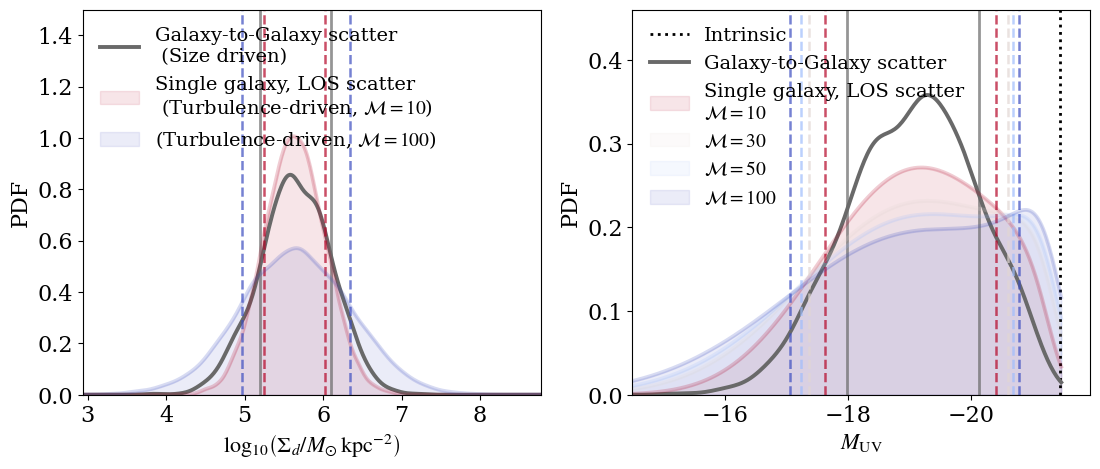

In [88]:
# --- Fig 6: fixed single-galaxy parameters (independent of global loop values) ---
_log_mh_6 = 10.86
_epsilon_6 = 0.1   # star-formation efficiency for this representative galaxy
_yd_6      = 0.1   # dust yield per SN [Msun/SN]
print(f"Fig 6 parameters: log_mh={_log_mh_6}, epsilon={_epsilon_6}, yd={_yd_6}, redshift={redshift}")

col_f = plt.colormaps["gray"]

np.random.seed(42)

# Stellar mass from halo mass
Mstar_array = halo_to_stellar_mass(10**_log_mh_6, fb, _epsilon_6)

# Build SFH
len_sp_dis = 1000
spin_param_distr = np.random.lognormal(mean=np.log(10**-1.5677), sigma=0.5390, size=len_sp_dis)
sfh, log_mst_build, age = star_formation_history(10**_log_mh_6, redshift, tstep, _epsilon_6)

n_sn_arr, md_arr = compute_mdust_steps(age, tstep, sfh, time_yr, log_snr_yr, _yd_6)

# Compute 1500A luminosity [erg/s/Hz]
l1500_arr = compute_l1500_steps(l1500_sb99, age, tstep, sfh, time_yr_l1500, method="SB99")
l1500_intr = l1500_arr[-1]  # intrinsic UV luminosity at final galaxy age [erg/s/Hz]
MUV_intr = l1500_to_muv_conv(l1500_intr)
print("MUV (intrinsic) -->", MUV_intr)


# ======== BUILD DUST SURFACE DENSITY DISTRIBUTION ===========
### === Setting up shell model with log-normal surface density fluctuations ===

M_dust = md_arr[-1]
print("log Mdust/Msun -->", np.log10(M_dust))
print("log Mstar/Msun -->", np.log10(Mstar_array))

# Median sigma_d for uniform distribution [g/cm^2]
tau_uv_arr = optical_depth(kuv, M_dust, 10**_log_mh_6, spin_param_distr, redshift)
Sigmad_arr = tau_uv_arr / kuv  # g/cm^2

# Log-normal draw for sigma_d, width set by Mach number
Sigmad_distr_10 = sample_surface_density(mu_sigma=np.median(Sigmad_arr), mach=10)
Sigmad_distr_100 = sample_surface_density(mu_sigma=np.median(Sigmad_arr), mach=100)

# Build the y-grid (dex) covering your histogram range
R_10 = density_compression_ratio(10)
sigma_ln_sigma_sq_10 = np.log(1 + (R_10 * 10**2) / 4)
sigma_ln_10 = np.sqrt(sigma_ln_sigma_sq_10)
mu_ln_10 = np.log(np.median(Sigmad_arr))
y_vals = np.linspace(-10, -2, 1000)  # dex
x_vals = 10**y_vals

# Transform to the PDF in y = log10 x (units: 1/dex)
pdf_y_10 = np.log(10) * x_vals * stats.lognorm.pdf(x_vals, s=sigma_ln_10, scale=np.exp(mu_ln_10))
# Overlay the correctly transformed PDF (no arbitrary /max)
# plt.plot(y_vals, pdf_y_10, label='PDF Mach=10 (correct in log10-space)', lw=2)


# -----------------------------
# 1) Build MUV distributions for spin-only and for Mach=10,300
# -----------------------------
K_SPINS = 13  # odd, so we include the exact median seed (u=0.5)
W_BLEND = 0.6  # blend between median-seed transmission and mean over seeds
N_LOS = 600  # LOS draws per Mach (distributed across seeds)
albedo = 0.3807
mach_vals = np.array([10, 30, 50, 100])

# exact-median spin seed and symmetric quantiles (data-driven via Sigmad_arr)
u_left = (np.arange(1, (K_SPINS // 2) + 1) - 0.5) / K_SPINS
u_mid = np.array([0.5])
u_right = 1.0 - u_left[::-1]
u_seeds = np.concatenate([u_left, u_mid, u_right])  # length = K_SPINS
mid_idx = K_SPINS // 2


t1500_uniform = transmission_sphere_mixed(tau_uv_arr)  # one value per halo/spin
l1500_uniform = l1500_intr * t1500_uniform
muv_att_spin = -2.5 * np.log10(l1500_uniform) + 51.60


# ------------------------------------
# Build extra Mach MUV distributions
# ------------------------------------

muv_clumpy = {mach: get_muv_clumpy(mach, Sigmad_arr, u_seeds, N_LOS, kuv, l1500_intr) for mach in mach_vals}


cmap = truncate_colormap(plt.cm.coolwarm_r, 0.0, 1.0)
mach_norm = (np.log10(mach_vals) - np.log10(mach_vals.min())) / (np.log10(mach_vals.max()) - np.log10(mach_vals.min()))
mach_colors = [cmap(v) for v in mach_norm]  # [color(M=10), color(30), color(50), color(100)]

# -----------------------------
# 2) Two-panel figure: Σ_d PDFs (left) + MUV PDFs (right)
# -----------------------------
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# ---- LEFT PANEL: Σ_d PDFs in log10-space (KDEs) ----

# conversion factor: g/cm^2 -> Msun/kpc^2
gcm2_to_msun_kpc2 = (const.kpc**2) / const.M_sun

# convert Σ_d samples to Msun/kpc^2 and take log10
log_sig_spin = np.log10(Sigmad_arr * gcm2_to_msun_kpc2)
log_sig_10 = np.log10(Sigmad_distr_10 * gcm2_to_msun_kpc2)
log_sig_100 = np.log10(Sigmad_distr_100 * gcm2_to_msun_kpc2)

logs_list = [log_sig_spin, log_sig_10, log_sig_100]

# common x-grid in log10(Σ_d / Msun kpc^-2)
x_sig_min = min(lg.min() for lg in logs_list)
x_sig_max = max(lg.max() for lg in logs_list)
x_sig = np.linspace(x_sig_min, x_sig_max, 400)

# colors & labels (left panel); use Mach colormap for 10 and 300
colors_sigma = [
    "dimgrey",  # uniform / spin-driven
    mach_colors[0],  # M=10
    mach_colors[-1],  # M=100
]
labels_sigma = [
    "Galaxy-to-Galaxy scatter\n (Size driven)",
    "Single galaxy, LOS scatter\n (Turbulence-driven, $\\mathcal{M}=10$)",
    "(Turbulence-driven, $\\mathcal{M}=100$)",
]

for i, (logs, col, lab) in enumerate(zip(logs_list, colors_sigma, labels_sigma)):
    kde = gaussian_kde(logs)  # KDE in log-space
    pdf = kde(x_sig)

    if i == 0:
        # Uniform: galaxy-to-galaxy scatter → thick solid line, no fill
        ax[0].plot(x_sig, pdf, color=col, lw=2.8, label=lab)
        p16, p84 = np.percentile(logs, [16, 84])
        ax[0].axvline(p16, color=col, linestyle="-", lw=2.0, alpha=0.7)
        ax[0].axvline(p84, color=col, linestyle="-", lw=2.0, alpha=0.7)
    else:
        # Turbulence: LOS-to-LOS scatter → shaded + dashed 16–84% lines
        ax[0].fill_between(x_sig, 0 * x_sig, pdf, color=col, alpha=0.1, label=lab, zorder=-1000 + i)
        ax[0].plot(x_sig, pdf, color=col, lw=2.8, alpha=0.2)
        p16, p84 = np.percentile(logs, [16, 84])
        ax[0].axvline(p16, color=col, linestyle="--", lw=1.8, alpha=0.7)
        ax[0].axvline(p84, color=col, linestyle="--", lw=1.8, alpha=0.7)

ax[0].set_xlabel(r"$\log_{10}\!\left(\Sigma_{d}/M_{\odot}\,\mathrm{kpc}^{-2}\right)$")
ax[0].set_ylabel(r"PDF")
ax[0].set_xlim(x_sig_min, x_sig_max)
ax[0].set_ylim(0, 1.5)
ax[0].legend(frameon=False, fontsize=14, loc="upper left")
# ---- RIGHT PANEL: MUV_att PDFs (KDEs), same Mach colors ----

# List including new Mach numbers
MUV_list = [muv_att_spin] + [muv_clumpy[mach] for mach in mach_vals]

# Colors & labels for right panel:
#   - first: uniform
#   - then: 10, 30, 100, 300 with colormap colors
colors_muv = ["dimgrey"] + mach_colors
labels_muv = [
    "Galaxy-to-Galaxy scatter",
    r"Single galaxy, LOS scatter" + "\n" + r"$\mathcal{M}=10$",
    r"$\mathcal{M}=30$",
    r"$\mathcal{M}=50$",
    r"$\mathcal{M}=100$",
]

# Build x-grid for MUV PDFs
all_muv = np.concatenate(MUV_list)
x_muv_min, x_muv_max = all_muv.min(), all_muv.max()
x_muv = np.linspace(x_muv_min, x_muv_max, 400)

# add MUV intrinsic line
ax[1].axvline(MUV_intr, color="black", linestyle=":", lw=2.0, label=r"Intrinsic")

for i, (arr, col, lab) in enumerate(zip(MUV_list, colors_muv, labels_muv)):
    kde = gaussian_kde(arr)
    pdf = kde(x_muv)

    if i == 0:
        # Uniform: galaxy-to-galaxy scatter (solid, no fill)
        ax[1].plot(x_muv, pdf, color=col, lw=2.8, label=lab)
        p16, p84 = np.percentile(arr, [16, 84])
        ax[1].axvline(p16, color=col, linestyle="-", lw=2.0, alpha=0.7)
        ax[1].axvline(p84, color=col, linestyle="-", lw=2.0, alpha=0.7)
    else:
        # Turbulence: LOS-to-LOS scatter → *shaded only* + dashed percentiles
        ax[1].fill_between(x_muv, 0 * x_muv, pdf, color=col, alpha=0.1, label=lab)
        ax[1].plot(x_muv, pdf, color=col, lw=2.8, alpha=0.2)
        p16, p84 = np.percentile(arr, [16, 84])
        ax[1].axvline(p16, color=col, linestyle="--", lw=1.8, alpha=0.7)
        ax[1].axvline(p84, color=col, linestyle="--", lw=1.8, alpha=0.7)


ax[1].set_xlabel(r"$M_{\rm UV}$")
ax[1].set_ylabel(r"PDF")
ax[1].set_ylim(0, 0.46)
ax[1].set_xlim(-14.5, MUV_intr - 0.5)  # keeps brighter magnitudes on the left
ax[1].legend(frameon=False, fontsize=14, loc="upper left")
print("\n\n Saving fig6_muv_pdf_clumpy.pdf")
fig.savefig(OUTPUT_DIR / "fig6_muv_pdf_clumpy.pdf", bbox_inches="tight")
plt.show()

## Figure 10: Greybody FIR SED — T_dust, CMB correction, observational constraints

For a representative halo (log Mh = 11.6), compute L_IR from the turbulent lognormal
Σ_d model (seed-averaged absorbed fraction, GL quadrature), invert the single-temperature
greybody to get T_dust, and plot the predicted observed-frame SED F_ν(λ_obs).

Key physics:
- CMB correction (da Cunha+13): T_CMB = 2.73*(1+z) sets a floor on T_dust and
  reduces the observable flux contrast against the CMB background
- κ_158(MW) > κ_158(stellar): MW dust predicts cooler T_d at fixed L_IR/M_d
- β_d = 2.03 (Draine+03 silicates)

Data:
- z=7:  REBELS detections at 158 µm (Inami+22), colour-coded by stellar mass
- z=10: ALMA and NOEMA upper limits (GNz11, GHZ2, GSz140), see refs. in the paper

Runs at redshift == 7 or redshift == 10.

SED halo: log Mh=10.86, log Mdust=6.62
MW dust (WD01), M=10: log(LIR/Lsun)=10.80, Td=40.4 K
MW dust (WD01), M=100: log(LIR/Lsun)=10.78, Td=40.1 K
Stellar dust (H19), M=10: log(LIR/Lsun)=10.42, Td=43.9 K
Stellar dust (H19), M=100: log(LIR/Lsun)=10.46, Td=44.7 K


 Saving fig10_greybody_sed_z10.pdf


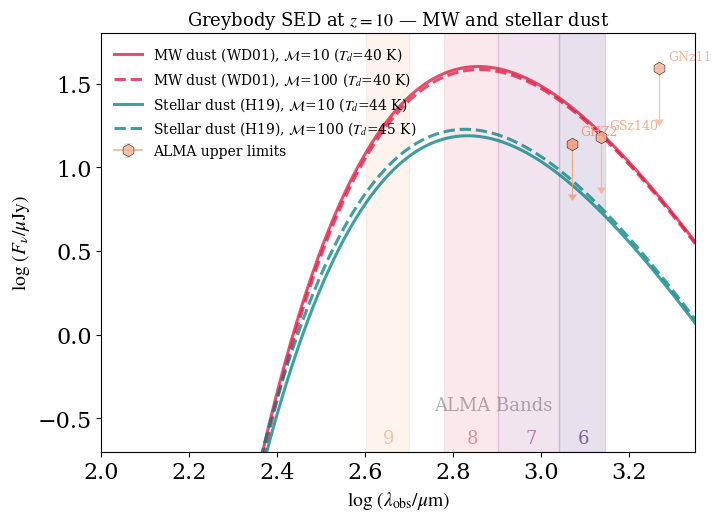

In [89]:
if redshift in (7, 10):
    # ── Colour normalisation — same as fig3 (tau_v plot) ─────────────────────
    # Recompute over the full Mh_array: Mstar_array has been overwritten with a
    # single-halo scalar by this point, so min() == max() gives wrong colours.
    _mstar_range = np.log10(halo_to_stellar_mass(Mh_array, fb, epsilon))
    _mstar_lo = _mstar_range.min()
    _mstar_hi = _mstar_range.max()
    def _sed_col(log_mstar):
        return custom_colormap((log_mstar - _mstar_lo) / (_mstar_hi - _mstar_lo))

    # ── Representative halo — match reference: 11.6 at z=7, 10.86 at z≥10 ──
    _log_mh_sed = 11.6 if redshift == 7 else 10.86
    _mh_sed = 10**_log_mh_sed
    _sfh_sed, _, _age_sed = star_formation_history(_mh_sed, redshift, tstep, epsilon)
    _l1500_sed = compute_l1500_steps(l1500_sb99, _age_sed, tstep, _sfh_sed, time_yr_l1500)[-1]
    _, _md_arr_sed = compute_mdust_steps(_age_sed, tstep, _sfh_sed, time_yr, log_snr_yr, yd)
    _mdust_sed = _md_arr_sed[-1]
    _spin_sed = np.random.lognormal(mean=np.log(10**-1.5677), sigma=0.5390, size=1000)
    _tau_sed = optical_depth(kuv, _mdust_sed, _mh_sed, _spin_sed, redshift)
    _sigmad_sed = _tau_sed / kuv
    print(f"SED halo: log Mh={_log_mh_sed}, log Mdust={np.log10(_mdust_sed):.2f}")

    # ── Dust model configurations ─────────────────────────────────────────────
    _sed_models = [
        {"name": "MW dust (WD01)",     "color": "crimson", "kUV_abs": kuv_drn_abs, "kIR": kir_drn},
        {"name": "Stellar dust (H19)", "color": "teal",    "kUV_abs": kuv_hir_abs, "kIR": kir_hir},
    ]
    _mach_sed = [10, 100]
    _ls_mach  = {10: "-", 100: "--"}

    lam_obs_um  = np.logspace(2, 4, 2000)
    lam_rest_um = lam_obs_um / (1.0 + redshift)
    lam_rest_cm = lam_rest_um * 1e-4

    # ── REBELS 158 µm detections (Sommovigo+22) ───────────────────────────────
    _reb_mstar = np.array([10.09, 9.56, 9.94, 9.22, 9.82, 9.38, 10.27,
                            10.16, 10.04, 9.78, 10.37, 9.24, 9.82])
    _reb_z     = np.array([6.496, 6.749, 7.346, 7.084, 7.675, 7.370, 7.307,
                            7.090, 6.685, 6.729, 6.577, 6.845, 7.365])
    _reb_flux  = np.array([67.23, 101.44, 86.78, 59.99, 52.87, 71.15, 259.55,
                            50.59, 56.08, 60.38, 163.00, 79.74, 48.28])
    _reb_eflux = np.array([13., 20., 24., 15., 10., 20., 22., 10., 13., 17., 23., 16., 13.])

    _yr_sed   = [0.8, 2.45] if redshift == 7 else [-0.7, 1.8]
    _band_bot = _yr_sed[0] + 0.05
    _band_lbl = _yr_sed[0] + 0.25

    fig10, ax10 = plt.subplots(figsize=(7.5, 5.5))

    for _mod in _sed_models:
        for _mach in _mach_sed:
            _lir = seedavg_lir(_mod["kUV_abs"], _mach, _sigmad_sed, _l1500_sed)
            _td  = dust_temp_from_lir(_lir, _mdust_sed, _mod["kIR"])
            print(f'{_mod["name"]}, M={_mach}: log(LIR/Lsun)={np.log10(_lir / const.L_sun):.2f}, Td={_td:.1f} K')
            _fnu = greybody_fnu(lam_rest_cm, _td, np.log10(_mdust_sed), redshift, _mod["kIR"])
            ax10.plot(np.log10(lam_obs_um), np.log10(_fnu),
                      color=_mod["color"], ls=_ls_mach[_mach], lw=2.2, alpha=0.75,
                      label=fr'{_mod["name"]}, $\mathcal{{M}}$={_mach} ($T_d$={_td:.0f} K)')

    # Overplot observational constraints — same colour normalisation as fig3
    if redshift == 7:
        for jj in range(len(_reb_z)):
            _fo, _dfo = _reb_flux[jj], _reb_eflux[jj]
            ax10.errorbar(
                np.log10(158.0 * _reb_z[jj]), np.log10(_fo),
                yerr=[[np.log10(_fo / max(_fo - _dfo, 1e-3))], [np.log10((_fo + _dfo) / _fo)]],
                ms=9, marker="s", capsize=2.5, mec="black", elinewidth=0.5,
                color=_sed_col(_reb_mstar[jj]), mew=0.3, alpha=0.85,
                label="REBELS (Inami+22)" if jj == 0 else None,
            )
    else:
        _uplim_mask = (jwst["IR_Flux"] > 0) & (jwst["lambda_obs"] > 0)
        _jw_ul = jwst[_uplim_mask]
        for _idx, _row in _jw_ul.iterrows():
            _lam_obs_jw = np.log10(_row["lambda_obs"] * (1.0 + _row["redshift"]))
            ax10.errorbar(
                _lam_obs_jw, np.log10(_row["IR_Flux"]),
                yerr=0.3, uplims=True,
                ms=9, marker="h", capsize=3, mec="black", elinewidth=0.8,
                color=_sed_col(_row["log_Mstar"]), mew=0.4, alpha=0.85,
                label="ALMA upper limits" if _idx == _jw_ul.index[0] else None,
            )
            ax10.text(_lam_obs_jw + 0.02, np.log10(_row["IR_Flux"]) + 0.05,
                      _row["name"], fontsize=9, color=_sed_col(_row["log_Mstar"]))

    _magma = plt.cm.magma(np.linspace(0.2, 0.8, 4))
    for _lo, _hi, _col, _lab in [
        (1.1e3, 1.4e3, _magma[0], "6"),
        (0.8e3, 1.1e3, _magma[1], "7"),
        (0.6e3, 0.8e3, _magma[2], "8"),
        (0.4e3, 0.5e3, _magma[3], "9"),
    ]:
        ax10.fill_betweenx(_yr_sed, np.log10(_lo), np.log10(_hi), color=_col, alpha=0.12, zorder=-100)
        ax10.text(np.log10(0.5 * (_lo + _hi)), _band_bot, _lab,
                  fontsize=13, color=_col, alpha=0.6, ha="center")
    ax10.text(np.log10(0.78e3), _band_lbl, "ALMA Bands", fontsize=13, alpha=0.3, ha="center")

    ax10.set_xlim(2.0, 3.35)
    ax10.set_ylim(*_yr_sed)
    ax10.set_xlabel(r"$\log\,(\lambda_{\rm obs}/\mu{\rm m})$", fontsize=14)
    ax10.set_ylabel(r"$\log\,(F_\nu/\mu{\rm Jy})$", fontsize=14)
    ax10.legend(frameon=False, fontsize=10, loc="upper left")
    ax10.set_title(rf"Greybody SED at $z={redshift}$ — MW and stellar dust", fontsize=13)
    plt.tight_layout()
    _sed_fname = f"fig10_greybody_sed_z{redshift}.pdf"
    print(f"\n\n Saving {_sed_fname}")
    fig10.savefig(OUTPUT_DIR / _sed_fname, bbox_inches="tight")
    plt.show()



## Figures 7-10

In [90]:
log_mh_array = np.linspace(8, 13, 70)

# ---- setup shared stuff ----
Mh_grid = 10**log_mh_array
dn_dlog_m = log_halo_mass_function(log_mh_array, redshift)  # [Mpc^-3 dex^-1]

In [91]:
lf_colormap = truncate_colormap(plt.colormaps["inferno"], 0.0, 0.7)

# ------------------------------------------------------------------------------------------
############# Loop in epsilon and yd: compute fract. of optically thick galaxies in the V-band
# ------------------------------------------------------------------------------------------
arr_e = np.array([0.05, 0.10, 0.20])  # [0.2])#0.05, 0.1, 0.6])
arr_yd = np.array([0.02, 0.3])  # , 0.3])
epsilon_colors = np.array([lf_colormap(0), lf_colormap(0.5), lf_colormap(1.0)])
# if i only run one
# epsilon_colors = np.array([lf_colormap(0.5), lf_colormap(0.5), lf_colormap(0.5)])



 Saving fig7_uv_lf_uniform_mw.pdf


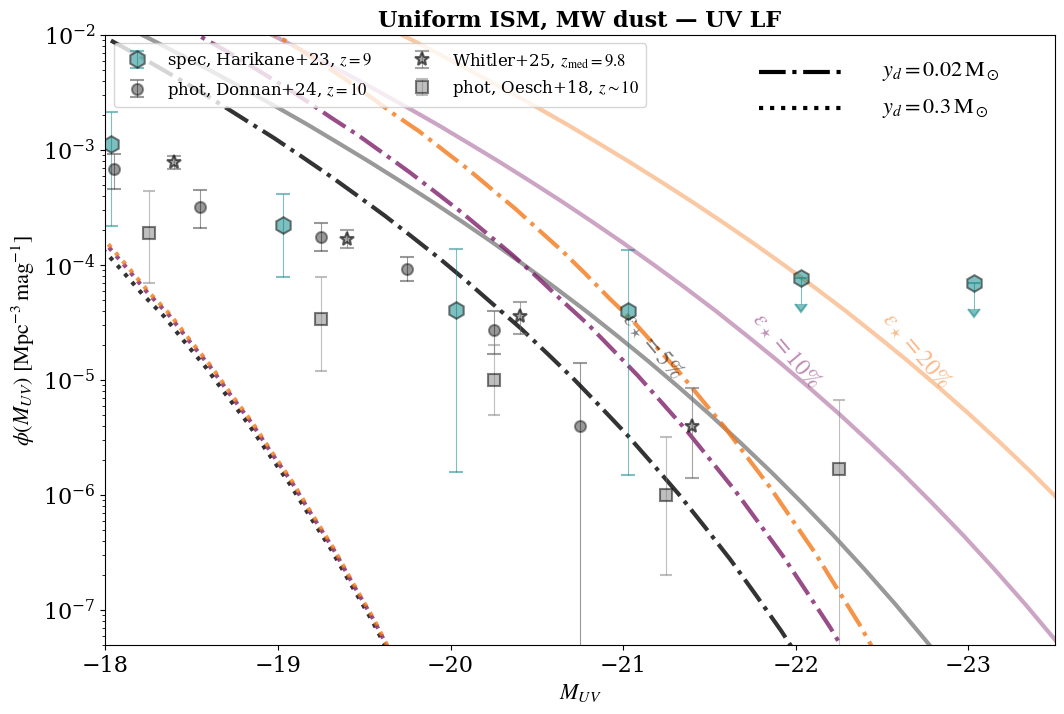

In [97]:
# -------------------------------------------------------
# Fig 7: Uniform ISM LF — MW dust (Draine WD01)
# Blend of median/mean transmission over spin distribution
# -------------------------------------------------------

# ---- dust model for this figure ----
_kuv_lf7 = kuv_drn      # UV extinction opacity [cm^2/g], MW WD01
_kuv_abs_lf7 = kuv_drn_abs  # UV absorption opacity [cm^2/g], MW WD01

# ---- knobs for the "in-between" behavior ----
K_SPINS = 7  # small number of stratified spins per mass (5–9 works well)
W_BLEND = 0.6  # 0=median, 1=mean; pick ~0.5–0.7 for "in-between"

# ---- setup shared stuff ----
Mh_grid = 10**log_mh_array
dn_dlog_m = log_halo_mass_function(log_mh_array, redshift)  # [Mpc^-3 dex^-1]
mu_ln, sig_ln = np.log(10**-1.5677), 0.5390

# fixed stratified quantiles in (0,1)
u = (np.arange(1, K_SPINS + 1) - 0.5) / K_SPINS
z = norm.ppf(u)  # standard-normal quantiles
spin_quant = np.exp(mu_ln + sig_ln * z)  # lognormal quantiles for lambda, shape (K_SPINS,)

_ir7_curves = []  # collect (logLIR, phi_ir, ls, color) for IR figure drawn after UV
fig, ax = plt.subplots(figsize=(11, 7))

for e, epsilon in enumerate(arr_e):
    # cache intrinsic + dust kernel once per (epsilon, Mh)
    L1500_grid = np.empty_like(log_mh_array, float)
    Md1_grid = np.empty_like(log_mh_array, float)  # final Md at yd=1

    for j, Mh in enumerate(Mh_grid):
        sfh, log_mst_build, age = star_formation_history(Mh, redshift, tstep, epsilon)
        L1500_grid[j] = compute_l1500_steps(l1500_sb99, age, tstep, sfh, time_yr_l1500)[-1]
        Md1_grid[j] = compute_mdust_steps(age, tstep, sfh, time_yr, log_snr_yr, yd=1.0)[1][-1]

    MUV_intr = l1500_to_muv_conv(L1500_grid)

    for yd in arr_yd:
        ls = ":" if yd == arr_yd[1] else "-."  # if yd == arr_yd[0] else ('--' if yd == arr_yd[1] else '-'))

        # scale dust kernel to this yd
        Md_grid = yd * Md1_grid

        # compute T for each stratified spin; blend mean/median => T_eff
        # loop over Mh (cheap: K_SPINS is small)
        T_eff = np.empty_like(Mh_grid, float)
        for j, Mh in enumerate(Mh_grid):
            # tau for K spins at this Mh
            tau_k = optical_depth(_kuv_lf7, Md_grid[j], Mh, spin_quant, redshift)  # expects vector spins
            TK = transmission_sphere_mixed(tau_k)  # shape (K_SPINS,)

            T_med = np.median(TK)
            T_mean = np.mean(TK)
            T_eff[j] = (1.0 - W_BLEND) * T_med + W_BLEND * T_mean

        # attenuated mags using the blended transmission
        MUV_att = l1500_to_muv_conv(T_eff * L1500_grid)

        # ---- Jacobian -> LFs ----
        dmuv_dlog_m_att = np.gradient(MUV_att, log_mh_array)
        dmuv_dlog_m_intr = np.gradient(MUV_intr, log_mh_array)

        # avoid zeros in derivative
        eps_der = 1e-6
        dmuv_dlog_m_att = np.where(
            np.abs(dmuv_dlog_m_att) < eps_der, np.sign(dmuv_dlog_m_att) * eps_der, dmuv_dlog_m_att
        )
        dmuv_dlog_m_intr = np.where(
            np.abs(dmuv_dlog_m_intr) < eps_der, np.sign(dmuv_dlog_m_intr) * eps_der, dmuv_dlog_m_intr
        )

        phi_att = dn_dlog_m / np.abs(dmuv_dlog_m_att)
        phi_intr = dn_dlog_m / np.abs(dmuv_dlog_m_intr)

        MUV_att, phi_att = enforce_monotonic(MUV_att, phi_att, direction="decreasing")
        MUV_intr, phi_intr = enforce_monotonic(MUV_intr, phi_intr, direction="decreasing")

        # numpy safety
        phi_att = np.where(np.isfinite(phi_att) & (phi_att > 0), phi_att, np.nan)
        phi_intr = np.where(np.isfinite(phi_intr) & (phi_intr > 0), phi_intr, np.nan)

        ax.plot(
            MUV_att, phi_att, lw=3.0, ls=ls, color=epsilon_colors[e], alpha=0.8
        )  # ,label=fr"ATT: $\epsilon$={epsilon}, $y_d$={yd}", alpha=0.9)#(K={K_SPINS}, w={W_BLEND})

        # ---- IR LF (z=7 only): compute and store for later ----
        if redshift == 7:
            A_eff7 = np.empty_like(Mh_grid, float)
            for j, Mh in enumerate(Mh_grid):
                tau_k_abs = optical_depth(_kuv_abs_lf7, Md_grid[j], Mh, spin_quant, redshift)
                AK = 1.0 - transmission_sphere_mixed(tau_k_abs)
                A_eff7[j] = (1.0 - W_BLEND) * np.median(AK) + W_BLEND * np.mean(AK)
            LIR7 = A_eff7 * L1500_grid * (3e10 / 1500e-8)
            LIR7 = np.where(LIR7 > 0, LIR7, np.nan)
            logLIR7 = np.log10(LIR7 / const.L_sun)
            dlogLIR7 = np.gradient(logLIR7, log_mh_array)
            dlogLIR7 = np.where(np.abs(dlogLIR7) < 1e-6, np.sign(dlogLIR7) * 1e-6, dlogLIR7)
            phi_ir7 = dn_dlog_m / np.abs(dlogLIR7)
            logLIR7, phi_ir7 = enforce_monotonic(logLIR7, phi_ir7, direction="increasing")
            phi_ir7 = np.where(np.isfinite(phi_ir7) & (phi_ir7 > 0), phi_ir7, np.nan)
            _ir7_curves.append((logLIR7.copy(), phi_ir7.copy(), ls, epsilon_colors[e]))

    if redshift >= 10:
        ax.plot(
            MUV_intr, phi_intr, lw=3.0, color=epsilon_colors[e], alpha=0.4, zorder=-10000
        )  # label=fr"Intrinsic, $\epsilon$={epsilon}"

        # in line text for clarity, specifying SF efficiency
        idx = int(0.6 * len(MUV_intr))
        x_eps = MUV_intr[idx - 1]
        y_eps = 1.3 * phi_intr[idx - 1]
        ax.text(
            x_eps,
            y_eps,
            rf"$\epsilon_\star={epsilon * 100:.0f}\%$",
            fontsize=17,
            color=epsilon_colors[e],
            rotation=-50,
            rotation_mode="anchor",
            ha="left",
            va="bottom",
            alpha=0.5,
        )


# Data & axes
plot_lf_data(redshift, ax=ax)
ax.set_yscale("log")
ax.set_ylabel(r"$\phi(M_{UV})\ [\mathrm{Mpc}^{-3}\,\mathrm{mag}^{-1}]$")
ax.set_xlabel(r"$M_{UV}$")
if redshift == 7:
    # plot vertican lines marking REBELS range
    ax.axvspan(-23, -21.0, color="lightskyblue", alpha=0.1, edgecolor="none", zorder=-1000)
    ax.text(-21.6, 0.8e-7, "REBELS", color="lightskyblue", alpha=0.35)
    ax.set_xlim(-19, -24.1)
    ax.set_ylim(0.5e-7, 1e-2)
else:
    ax.set_xlim(-18, -23.5)  # more negative MUV = brighter; bright end on RIGHT
    ax.set_ylim(0.5e-7, 1e-2)

# ---- Big free-floating labels — drawn after xlim so line length is a fixed fraction ----
_xlim7 = ax.get_xlim()
_dr7 = abs(_xlim7[1] - _xlim7[0])  # data range in mag
_trans7 = blended_transform_factory(ax.transData, ax.transAxes)
_x_lbl = -22.5
_line_frac7 = 0.08 if redshift == 7 else 0.09
_x_lb = _x_lbl + 0.04 * _dr7   # right end of line (gap before text)
_x_la = _x_lb  + _line_frac7 * _dr7   # left end of line

y0 = 0.94
ax.plot([_x_la, _x_lb], [y0, y0], transform=_trans7, color="black", lw=3, ls="-.")
ax.text(_x_lbl, y0, r"$y_d = 0.02\,\mathrm{M_\odot}$",
        transform=_trans7, fontsize=16, color="black", ha="left", va="center")
y1 = 0.88
ax.plot([_x_la, _x_lb], [y1, y1], transform=_trans7, color="black", lw=3, ls=":")
ax.text(_x_lbl, y1, r"$y_d = 0.3\,\mathrm{M_\odot}$",
        transform=_trans7, fontsize=16, color="black", ha="left", va="center")

if redshift != 10:
    y_eps0 = 0.81
    dy = 0.06
    for e, epsilon in enumerate(arr_e):
        y_here = y_eps0 - e * dy
        ax.plot([_x_la, _x_lb], [y_here, y_here],
                transform=_trans7, color=epsilon_colors[e], lw=4, ls="-")
        ax.text(_x_lbl, y_here, rf"$\epsilon_\star={epsilon * 100:.0f}\%$",
                transform=_trans7, fontsize=17, color=epsilon_colors[e], ha="left", va="center")

ax.legend(fontsize=12, ncols=2, loc="upper left")
ax.set_title("Uniform ISM, MW dust — UV LF", fontsize=16, fontweight="bold")

plt.subplots_adjust(left=0.12, bottom=0.087, right=0.983, top=0.958, wspace=0.2, hspace=0.2)

print("\n\n Saving fig7_uv_lf_uniform_mw.pdf")
fig.savefig(OUTPUT_DIR / "fig7_uv_lf_uniform_mw.pdf", bbox_inches="tight")
plt.show()

if redshift == 7:
    fig_ir7, ax_ir7 = plt.subplots(figsize=(9, 7))
    for _lir, _phi, _ls, _col in _ir7_curves:
        ax_ir7.plot(_lir, _phi, lw=3.0, ls=_ls, color=_col, alpha=0.95)
    rebels_ir = pd.read_csv(DATA_DIR / "REBELS_z7_IR_LF_Barrufet23.csv", comment="#")
    phi_data = 10 ** rebels_ir["log_phi"]
    phi_uerr = 10 ** (rebels_ir["log_phi"] + rebels_ir["log_phi_err_high"]) - phi_data
    phi_lerr = phi_data - 10 ** (rebels_ir["log_phi"] - rebels_ir["log_phi_err_low"])
    phi_lerr = np.minimum(phi_lerr, 0.99 * phi_data)
    phi_uerr = np.minimum(phi_uerr, 0.99 * phi_data)
    ax_ir7.errorbar(rebels_ir["log_LIR"], phi_data, yerr=[phi_lerr, phi_uerr],
                    ls="none", marker="s", ms=10, capsize=5, alpha=0.7, color="darkred",
                    label="REBELS\n Barrufet+23, $z=7$", mew=1.5, mec="black", elinewidth=0.8)
    ax_ir7.set_yscale("log")
    ax_ir7.set_ylabel(r"$\phi(\log_{10} L_{\mathrm{IR}})\ [\mathrm{Mpc}^{-3}\,\mathrm{dex}^{-1}]$")
    ax_ir7.set_xlabel(r"$\log_{10}(L_{\mathrm{IR}}/L_{\odot})$")
    ax_ir7.set_ylim(1.0e-7, 1e-3)
    ax_ir7.set_xlim(10.4, 13.4)
    ax_ir7.legend(fontsize=12, ncols=2, loc="upper right")
    ax_ir7.set_title("Uniform ISM, MW dust — IR LF", fontsize=16, fontweight="bold")
    print("\n\n Saving fig7_ir_lf_uniform_mw.pdf")
    fig_ir7.savefig(OUTPUT_DIR / "fig7_ir_lf_uniform_mw.pdf", bbox_inches="tight")
    plt.show()



 Saving fig8_uv_lf_uniform_stellar.pdf


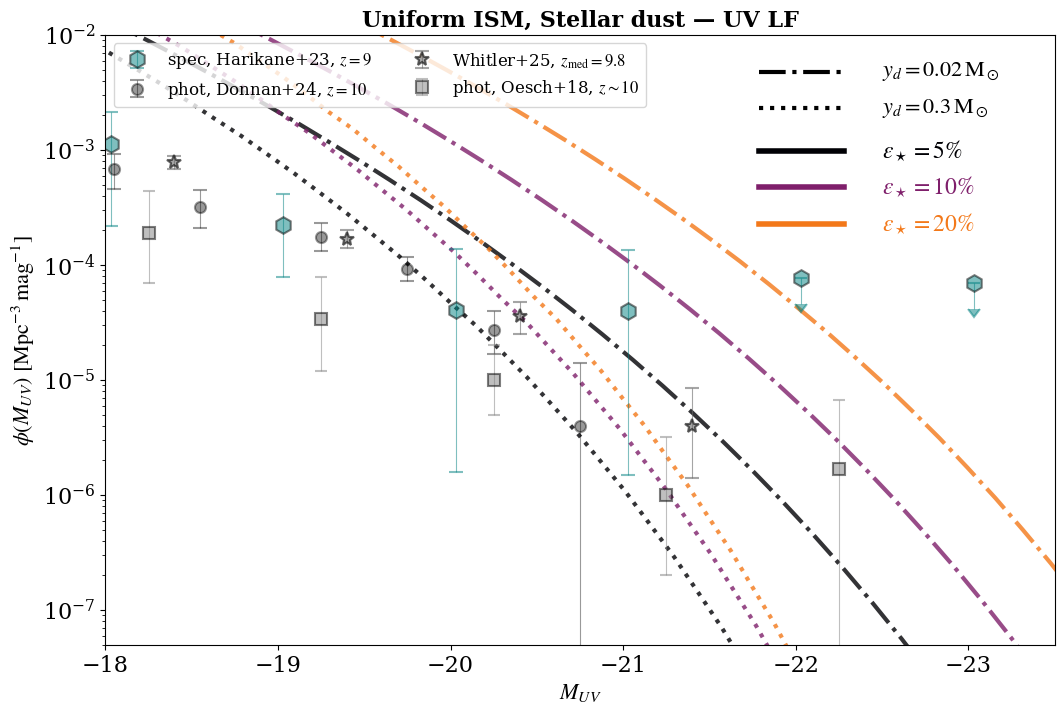



epsilon =  0.05


epsilon =  0.1


epsilon =  0.2


 Saving fig9_uv_ir_lf_clumpy_mw.pdf


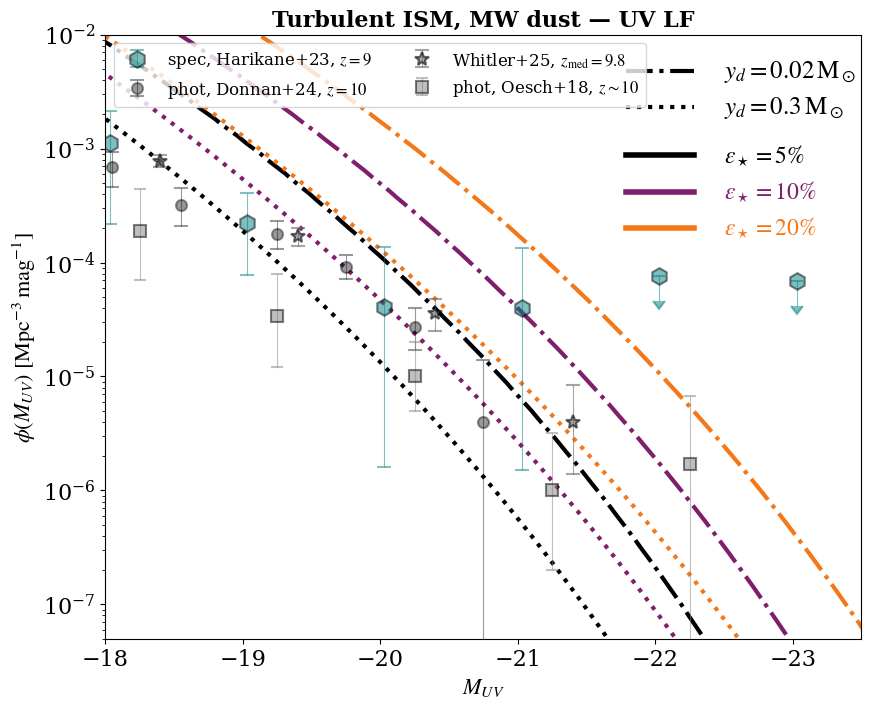



epsilon =  0.05


epsilon =  0.1


epsilon =  0.2


 Saving fig9_uv_ir_lf_clumpy_stellar.pdf


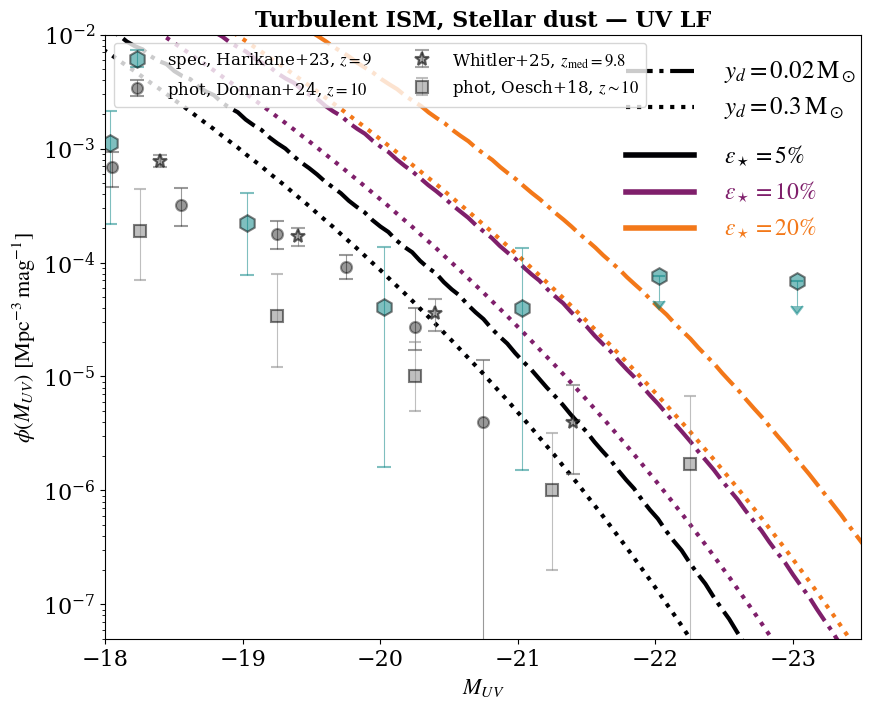

In [98]:
# -------------------------------------------------------
# Fig 8: Uniform ISM LF — stellar dust (Hirashita+19)
# Same method as fig7 but with stellar dust opacities
# -------------------------------------------------------

# ---- dust model for this figure ----
_kuv_lf8 = kuv_hir      # UV extinction opacity [cm^2/g], stellar dust
_kuv_abs_lf8 = kuv_hir_abs  # UV absorption opacity [cm^2/g], stellar dust

# ---- same knobs ----
K_SPINS = 7
W_BLEND = 0.6

# ---- setup shared stuff ----
Mh_grid = 10**log_mh_array
dn_dlog_m = log_halo_mass_function(log_mh_array, redshift)
mu_ln, sig_ln = np.log(10**-1.5677), 0.5390

u = (np.arange(1, K_SPINS + 1) - 0.5) / K_SPINS
z = norm.ppf(u)
spin_quant = np.exp(mu_ln + sig_ln * z)

_ir8_curves = []  # collect (logLIR, phi_ir, ls, color) for IR figure drawn after UV
fig, ax = plt.subplots(figsize=(11, 7))

for e, epsilon in enumerate(arr_e):
    L1500_grid = np.empty_like(log_mh_array, float)
    Md1_grid = np.empty_like(log_mh_array, float)

    for j, Mh in enumerate(Mh_grid):
        sfh, log_mst_build, age = star_formation_history(Mh, redshift, tstep, epsilon)
        L1500_grid[j] = compute_l1500_steps(l1500_sb99, age, tstep, sfh, time_yr_l1500)[-1]
        Md1_grid[j] = compute_mdust_steps(age, tstep, sfh, time_yr, log_snr_yr, yd=1.0)[1][-1]

    MUV_intr = l1500_to_muv_conv(L1500_grid)

    for yd in arr_yd:
        ls = ":" if yd == arr_yd[1] else "-."

        Md_grid = yd * Md1_grid

        T_eff = np.empty_like(Mh_grid, float)
        for j, Mh in enumerate(Mh_grid):
            tau_k = optical_depth(_kuv_lf8, Md_grid[j], Mh, spin_quant, redshift)
            TK = transmission_sphere_mixed(tau_k)
            T_med = np.median(TK)
            T_mean = np.mean(TK)
            T_eff[j] = (1.0 - W_BLEND) * T_med + W_BLEND * T_mean

        MUV_att = l1500_to_muv_conv(T_eff * L1500_grid)

        dmuv_dlog_m_att = np.gradient(MUV_att, log_mh_array)
        dmuv_dlog_m_intr = np.gradient(MUV_intr, log_mh_array)

        eps_der = 1e-6
        dmuv_dlog_m_att = np.where(
            np.abs(dmuv_dlog_m_att) < eps_der, np.sign(dmuv_dlog_m_att) * eps_der, dmuv_dlog_m_att
        )
        dmuv_dlog_m_intr = np.where(
            np.abs(dmuv_dlog_m_intr) < eps_der, np.sign(dmuv_dlog_m_intr) * eps_der, dmuv_dlog_m_intr
        )

        phi_att = dn_dlog_m / np.abs(dmuv_dlog_m_att)
        phi_intr = dn_dlog_m / np.abs(dmuv_dlog_m_intr)

        MUV_att, phi_att = enforce_monotonic(MUV_att, phi_att, direction="decreasing")
        MUV_intr, phi_intr = enforce_monotonic(MUV_intr, phi_intr, direction="decreasing")

        phi_att = np.where(np.isfinite(phi_att) & (phi_att > 0), phi_att, np.nan)
        phi_intr = np.where(np.isfinite(phi_intr) & (phi_intr > 0), phi_intr, np.nan)

        ax.plot(MUV_att, phi_att, lw=3.0, ls=ls, color=epsilon_colors[e], alpha=0.8)

        # ---- IR LF (z=7 only): compute and store for later ----
        if redshift == 7:
            A_eff8 = np.empty_like(Mh_grid, float)
            for j, Mh in enumerate(Mh_grid):
                tau_k_abs = optical_depth(_kuv_abs_lf8, Md_grid[j], Mh, spin_quant, redshift)
                AK = 1.0 - transmission_sphere_mixed(tau_k_abs)
                A_eff8[j] = (1.0 - W_BLEND) * np.median(AK) + W_BLEND * np.mean(AK)
            LIR8 = A_eff8 * L1500_grid * (3e10 / 1500e-8)
            LIR8 = np.where(LIR8 > 0, LIR8, np.nan)
            logLIR8 = np.log10(LIR8 / const.L_sun)
            dlogLIR8 = np.gradient(logLIR8, log_mh_array)
            dlogLIR8 = np.where(np.abs(dlogLIR8) < 1e-6, np.sign(dlogLIR8) * 1e-6, dlogLIR8)
            phi_ir8 = dn_dlog_m / np.abs(dlogLIR8)
            logLIR8, phi_ir8 = enforce_monotonic(logLIR8, phi_ir8, direction="increasing")
            phi_ir8 = np.where(np.isfinite(phi_ir8) & (phi_ir8 > 0), phi_ir8, np.nan)
            _ir8_curves.append((logLIR8.copy(), phi_ir8.copy(), ls, epsilon_colors[e]))


# Data & axes
plot_lf_data(redshift, ax=ax)
ax.set_yscale("log")
ax.set_ylabel(r"$\phi(M_{UV})\ [\mathrm{Mpc}^{-3}\,\mathrm{mag}^{-1}]$")
ax.set_xlabel(r"$M_{UV}$")
if redshift == 7:
    ax.axvspan(-23, -21.0, color="lightskyblue", alpha=0.1, edgecolor="none", zorder=-1000)
    ax.text(-21.6, 0.8e-7, "REBELS", color="lightskyblue", alpha=0.35)
    ax.set_xlim(-19, -24.1)
    ax.set_ylim(0.5e-7, 1e-2)
else:
    ax.set_xlim(-18, -23.5)
    ax.set_ylim(0.5e-7, 1e-2)

# ---- Big free-floating labels — drawn after xlim so line length is a fixed fraction ----
_xlim8 = ax.get_xlim()
_dr8 = abs(_xlim8[1] - _xlim8[0])
_trans8 = blended_transform_factory(ax.transData, ax.transAxes)
_x_lbl = -22.5
_line_frac8 = 0.08 if redshift == 7 else 0.09
_x_lb = _x_lbl + 0.04 * _dr8
_x_la = _x_lb  + _line_frac8 * _dr8

y0 = 0.94
ax.plot([_x_la, _x_lb], [y0, y0], transform=_trans8, color="black", lw=3, ls="-.")
ax.text(_x_lbl, y0, r"$y_d = 0.02\,\mathrm{M_\odot}$",
        transform=_trans8, fontsize=16, color="black", ha="left", va="center")
y1 = 0.88
ax.plot([_x_la, _x_lb], [y1, y1], transform=_trans8, color="black", lw=3, ls=":")
ax.text(_x_lbl, y1, r"$y_d = 0.3\,\mathrm{M_\odot}$",
        transform=_trans8, fontsize=16, color="black", ha="left", va="center")

y_eps0 = 0.81
dy = 0.06
for e, epsilon in enumerate(arr_e):
    y_here = y_eps0 - e * dy
    ax.plot([_x_la, _x_lb], [y_here, y_here],
            transform=_trans8, color=epsilon_colors[e], lw=4, ls="-")
    ax.text(_x_lbl, y_here, rf"$\epsilon_\star={epsilon * 100:.0f}\%$",
            transform=_trans8, fontsize=17, color=epsilon_colors[e], ha="left", va="center")

ax.legend(fontsize=12, ncols=2, loc="upper left")
ax.set_title("Uniform ISM, Stellar dust — UV LF", fontsize=16, fontweight="bold")
plt.subplots_adjust(left=0.12, bottom=0.087, right=0.983, top=0.958, wspace=0.2, hspace=0.2)

print("\n\n Saving fig8_uv_lf_uniform_stellar.pdf")
fig.savefig(OUTPUT_DIR / "fig8_uv_lf_uniform_stellar.pdf", bbox_inches="tight")
plt.show()

if redshift == 7:
    fig_ir8, ax_ir8 = plt.subplots(figsize=(9, 7))
    for _lir, _phi, _ls, _col in _ir8_curves:
        ax_ir8.plot(_lir, _phi, lw=3.0, ls=_ls, color=_col, alpha=0.95)
    rebels_ir = pd.read_csv(DATA_DIR / "REBELS_z7_IR_LF_Barrufet23.csv", comment="#")
    phi_data = 10 ** rebels_ir["log_phi"]
    phi_uerr = 10 ** (rebels_ir["log_phi"] + rebels_ir["log_phi_err_high"]) - phi_data
    phi_lerr = phi_data - 10 ** (rebels_ir["log_phi"] - rebels_ir["log_phi_err_low"])
    phi_lerr = np.minimum(phi_lerr, 0.99 * phi_data)
    phi_uerr = np.minimum(phi_uerr, 0.99 * phi_data)
    ax_ir8.errorbar(rebels_ir["log_LIR"], phi_data, yerr=[phi_lerr, phi_uerr],
                    ls="none", marker="s", ms=10, capsize=5, alpha=0.7, color="darkred",
                    label="REBELS\n Barrufet+23, $z=7$", mew=1.5, mec="black", elinewidth=0.8)
    ax_ir8.set_yscale("log")
    ax_ir8.set_ylabel(r"$\phi(\log_{10} L_{\mathrm{IR}})\ [\mathrm{Mpc}^{-3}\,\mathrm{dex}^{-1}]$")
    ax_ir8.set_xlabel(r"$\log_{10}(L_{\mathrm{IR}}/L_{\odot})$")
    ax_ir8.set_ylim(1.0e-7, 1e-3)
    ax_ir8.set_xlim(10.4, 13.4)
    ax_ir8.legend(fontsize=12, ncols=2, loc="upper right")
    ax_ir8.set_title("Uniform ISM, Stellar dust — IR LF", fontsize=16, fontweight="bold")
    print("\n\n Saving fig8_ir_lf_uniform_stellar.pdf")
    fig_ir8.savefig(OUTPUT_DIR / "fig8_ir_lf_uniform_stellar.pdf", bbox_inches="tight")
    plt.show()



# ============================================
# Fig 9: Clumpy (turbulent) ISM LF — MW dust (Draine+03)
# Lachlan method: lognormal Σ_d CDF, geometry + turbulence scatter
# Two-panel (UV, IR) only when redshift == 7; otherwise UV-only
# ============================================

# ---- knobs ----
K_SPINS = 21  # used only to estimate geometry-induced Σ_d scatter
Mach = 30  # clumpy ISM width (lognormal σ for Σ_d from turbulence)
albedo = 0.3807
K_U = 24  # Gauss–Legendre nodes for Σ_d integral (IR)

# ---- shared stuff ----
Mh_grid = 10**log_mh_array
dn_dlog_m = log_halo_mass_function(log_mh_array, redshift)  # [Mpc^-3 dex^-1]

# spin distribution (for geometry scatter)
mu_ln_spin, sig_ln_spin = np.log(10**-1.5677), 0.5390
u_left = (np.arange(1, (K_SPINS // 2) + 1) - 0.5) / K_SPINS
u_mid = np.array([0.5])
u_right = 1.0 - u_left[::-1]
u = np.concatenate([u_left, u_mid, u_right])  # length = K_SPINS
z_spin = norm.ppf(u)
spin_quant = np.exp(mu_ln_spin + sig_ln_spin * z_spin)  # (K_SPINS,)
mid_idx = K_SPINS // 2


sigma_turb = lognormal_variance_from_mach(Mach)

# Gauss–Legendre nodes for Σ_d integral (in z-space)
xu, wu = np.polynomial.legendre.leggauss(K_U)
u_nodes = np.clip(0.5 * (xu + 1.0), 1e-12, 1 - 1e-12)
w_nodes = 0.5 * wu
z_nodes = norm.ppf(u_nodes)

# --- invert T_1500_sphere_im: precompute τ(T) lookup once ---
tau_max_lookup = 20.0
N_tau = 4000
tau_grid = np.linspace(1e-3, tau_max_lookup, N_tau)  # start > 0: T_sphere_mixed(0) is undefined
T_grid = transmission_sphere_mixed(tau_grid)  # T(τ) for UV

# make T increasing for interpolation τ(T)
T_rev = T_grid[::-1]
tau_rev = tau_grid[::-1]


def tau_of_t(t_target: float | np.ndarray) -> np.ndarray:
    """Invert T_1500_sphere_im(τ) ≈ t_target by interpolation.

    Parameters
    ----------
    t_target:
        Target transmission value(s) in (0, 1]; vectorized.

    Returns
    -------
    np.ndarray
        Optical depth τ corresponding to each transmission value.

    """
    t_target = np.asarray(t_target)
    # clip into the range of precomputed T
    t_clipped = np.clip(t_target, T_rev[0], T_rev[-1])
    return np.interp(t_clipped, T_rev, tau_rev)


# helpers
def _nz(x: np.ndarray) -> np.ndarray:
    """Replace near-zero values with a small signed constant to avoid division by zero."""
    return np.where(np.abs(x) < 1e-6, np.sign(x) * 1e-6, x)


def _lf_from_curve_sg(x_of_mh: np.ndarray, window: int = 9, poly: int = 2) -> np.ndarray:
    # choose an odd window: 7/9/11 depending on len(log_mh_array)
    win = max(7, min(window, len(log_mh_array) - (1 - len(log_mh_array) % 2)))
    dx_dlog_mh = savgol_filter(x_of_mh, win, poly, deriv=1, delta=np.mean(np.diff(log_mh_array)), mode="interp")
    dx_dlog_mh = _nz(dx_dlog_mh)
    return dn_dlog_m / np.abs(dx_dlog_mh)


for _kuv_lf9, _kuv_abs_lf9, _dust_label, _fig9_fname in [
    (kuv_drn, kuv_drn_abs, "MW dust", "fig9_uv_ir_lf_clumpy_mw.pdf"),
    (kuv_hir, kuv_hir_abs, "Stellar dust", "fig9_uv_ir_lf_clumpy_stellar.pdf"),
]:
    # ============================================
    # Figure setup: IR panel only if z=7
    # ============================================
    if redshift == 7:
        fig = plt.figure(figsize=(15, 6.5))
        gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])
        ax_uv = fig.add_subplot(gs[0])
        ax_ir = fig.add_subplot(gs[1])
        show_ir = True
    else:
        fig, ax_uv = plt.subplots(figsize=(9, 7))
        ax_ir = None
        show_ir = False

    for e, epsilon in enumerate(arr_e):
        color = epsilon_colors[e]
        print("\n")
        print("epsilon = ", epsilon)

        # ---------- intrinsic L1500 and Md kernel per Mh (ε-dependent) ----------
        L1500_grid = np.empty_like(log_mh_array, float)
        Md1_grid = np.empty_like(log_mh_array, float)  # Md at yd=1
        for j, Mh in enumerate(Mh_grid):
            sfh, log_mst_build, age = star_formation_history(Mh, redshift, tstep, epsilon)
            L1500_grid[j] = compute_l1500_steps(l1500_sb99, age, tstep, sfh, time_yr_l1500)[-1]
            Md1_grid[j] = compute_mdust_steps(age, tstep, sfh, time_yr, log_snr_yr, yd=1.0)[1][-1]

        # Intrinsic UV LF (no dust):
        MUV_intr_per_halo = l1500_to_muv_conv(L1500_grid)  # per halo
        MUV_intr = MUV_intr_per_halo.copy()
        phi_intr = _lf_from_curve_sg(MUV_intr)
        MUV_intr, phi_intr = enforce_monotonic(MUV_intr, phi_intr, direction="decreasing")

        # magnitude grid for analytic UV LF
        Mbright = MUV_intr.min() - 1.0  # slightly brighter
        Mfaint = MUV_intr.max() + 1.0  # slightly fainter
        MUV_grid = np.linspace(Mbright, Mfaint, 250)
        n_mh = len(Mh_grid)
        n_m = len(MUV_grid)

        for yd in arr_yd:
            ls = ":" if yd == arr_yd[1] else "-."

            # scale dust kernel to this yd
            Md_grid = yd * Md1_grid

            # ---------- geometry-induced Σ_d from spins (per halo) ----------
            tau_k_grid = np.empty((n_mh, K_SPINS))
            Sigma0 = np.empty(n_mh)
            sigma_geom = np.empty(n_mh)
            for j, Mh in enumerate(Mh_grid):
                tau_k = optical_depth(_kuv_lf9, Md_grid[j], Mh, spin_quant, redshift)  # (K_SPINS,)
                tau_k_grid[j, :] = tau_k
                SigmaK = tau_k / _kuv_lf9

                # lognormal fit to Σ_d distribution from geometry
                ln_sigma_k = np.log(SigmaK)
                Sigma0[j] = np.exp(np.mean(ln_sigma_k))  # geometric mean
                sigma_geom[j] = np.std(ln_sigma_k)  # ln-space scatter

            # effective Σ_d scatter: geometry + turbulence (independent)
            sigma_eff = np.sqrt(sigma_geom**2 + sigma_turb**2)

            # ---------- uniform-screen UV LF (no clumpiness; median spin) ----------
            tau_med = tau_k_grid[:, mid_idx]  # median over spins
            T_uniform = transmission_sphere_mixed(tau_med)
            MUV_uniform = l1500_to_muv_conv(T_uniform * L1500_grid)
            phi_uniform = _lf_from_curve_sg(MUV_uniform)
            MUV_uniform, phi_uniform = enforce_monotonic(MUV_uniform, phi_uniform, direction="decreasing")

            # show uniform curve in faint dashed for reference
            # ax_uv.plot(MUV_uniform, phi_uniform, lw=0.5, ls=ls,
            #           color=color, alpha=0.4)

            # ---------- CLUMPY UV: use lognormal Σ_d + T_1500_sphere_im ----------
            # f_all[j, i] = fraction of galaxies at Mh_j brighter than MUV_grid[i]
            f_all = np.zeros((n_mh, n_m))
            df_dm = np.zeros_like(f_all)

            for j in range(n_mh):
                M_int_j = MUV_intr_per_halo[j]
                Sigma0_j = Sigma0[j]
                sigma_j = sigma_eff[j]

                if not np.isfinite(Sigma0_j) or Sigma0_j <= 0.0 or sigma_j <= 0.0:
                    continue

                # required transmission for each M: T_star = Lobs/Lint
                T_star = 10 ** (-0.4 * (MUV_grid - M_int_j))  # can be >1 (unphysical)
                # physically, T_star > 1 means "need brightening" → f = 0
                valid_t = (T_star > 0.0) & (T_star <= 1.0)

                tau_max = np.zeros_like(MUV_grid)
                if np.any(valid_t):
                    tau_max[valid_t] = tau_of_t(T_star[valid_t])

                Sigma_max = tau_max / _kuv_lf9  # Σ_d,max(M, Mh_j)

                # lognormal CDF: f = P(Σ_d < Σ_max)
                f_mj = np.zeros_like(MUV_grid)
                positive = Sigma_max > 0.0
                if np.any(positive):
                    z_ln = (np.log(Sigma_max[positive]) - np.log(Sigma0_j)) / (np.sqrt(2.0) * sigma_j)
                    f_mj[positive] = 0.5 * (1.0 + special.erf(z_ln))

                f_all[j, :] = f_mj

                # derivative df/dM for this halo (central finite difference)
                df = np.zeros_like(MUV_grid)
                # central points
                df[1:-1] = (f_mj[2:] - f_mj[:-2]) / (MUV_grid[2:] - MUV_grid[:-2])
                # edges
                df[0] = (f_mj[1] - f_mj[0]) / (MUV_grid[1] - MUV_grid[0])
                df[-1] = (f_mj[-1] - f_mj[-2]) / (MUV_grid[-1] - MUV_grid[-2])
                df_dm[j, :] = df

            # integrate over halo mass to get φ(M)
            phi_clumpy = np.zeros_like(MUV_grid)
            for i in range(n_m):
                integrand = dn_dlog_m * df_dm[:, i]
                phi_clumpy[i] = np.trapezoid(integrand, log_mh_array)

            # smooth φ(M) in log-space to reduce numerical wiggles
            logphi = np.log10(np.clip(phi_clumpy, 1e-12, None))
            win_m = max(11, min(41, (len(MUV_grid) // 3) * 2 + 1))  # odd window
            logphi_s = savgol_filter(logphi, win_m, 3, mode="interp")
            phi_clumpy_s = 10**logphi_s

            # enforce monotonic non-decreasing φ(M) as M increases (fainter → higher φ)
            phi_mon = phi_clumpy_s.copy()
            for i in range(1, len(phi_mon)):
                if phi_mon[i] < phi_mon[i - 1]:
                    phi_mon[i] = phi_mon[i - 1]
            phi_clumpy_s = phi_mon

            # ---------- IR LF: same Σ_d lognormal + T_1500_sphere_im ----------
            LIR_med = np.empty_like(log_mh_array, float)
            for j, Mh in enumerate(Mh_grid):
                L1500 = L1500_grid[j]
                mu_ln_sigma = np.log(Sigma0[j])
                sigma_j = sigma_eff[j]

                x_nodes = np.exp(mu_ln_sigma + sigma_j * z_nodes)  # Σ_d quadrature nodes
                T_abs_nodes = transmission_sphere_mixed(_kuv_abs_lf9 * x_nodes)
                A_nodes = 1.0 - T_abs_nodes

                f_abs = np.sum(w_nodes * A_nodes)  # average absorbed fraction
                LIR_med[j] = (L1500 * f_abs * (3e10 / (1500e-8))) / const.L_sun

            LIR_med = np.where(LIR_med > 0, LIR_med, np.nan)
            log_lir_med = np.log10(LIR_med)
            phi_ir = _lf_from_curve_sg(log_lir_med)
            log_lir_med, phi_ir = enforce_monotonic(log_lir_med, phi_ir, direction="increasing")
            phi_ir = np.where(np.isfinite(phi_ir) & (phi_ir > 0), phi_ir, np.nan)

            # ---------- plotting ----------
            # clumpy UV LF
            ax_uv.plot(MUV_grid, phi_clumpy_s, lw=3.0, ls=ls, color=color)

            # IR LF (only if z=7)
            if show_ir:
                ax_ir.plot(log_lir_med, phi_ir, lw=3.0, ls=ls, color=color, alpha=0.95)

    # --- cosmetics ---
    plot_lf_data(redshift, ax=ax_uv)
    ax_uv.set_yscale("log")
    ax_uv.set_ylabel(r"$\phi(M_{UV})\ [\mathrm{Mpc}^{-3}\,\mathrm{mag}^{-1}]$")
    ax_uv.set_xlabel(r"$M_{UV}$")

    if redshift == 7:
        ax_uv.set_xlim(-19.0, -24.1)
        ax_uv.set_ylim(0.5e-7, 1e-2)
        ax_uv.axvspan(-23, -21.0, color="lightskyblue", alpha=0.1, edgecolor="none", zorder=-1000)
        ax_uv.text(-21.6, 0.8e-7, "REBELS", color="lightskyblue", alpha=0.35)
    else:
        ax_uv.set_xlim(-18, -23.5)
        ax_uv.set_ylim(0.5e-7, 1e-2)

    # ---- Big free-floating labels — drawn after xlim so line length is a fixed fraction ----
    _xlim9 = ax_uv.get_xlim()
    _dr9 = abs(_xlim9[1] - _xlim9[0])
    _trans9 = blended_transform_factory(ax_uv.transData, ax_uv.transAxes)
    _x_lbl = -22.5
    _line_frac9 = 0.08 if redshift == 7 else 0.09
    _x_lb = _x_lbl + 0.04 * _dr9
    _x_la = _x_lb  + _line_frac9 * _dr9

    y0 = 0.87 if redshift == 7 else 0.94
    ax_uv.plot([_x_la, _x_lb], [y0, y0], transform=_trans9, color="black", lw=3, ls="-.")
    ax_uv.text(_x_lbl, y0, r"$y_d = 0.02\,\mathrm{M_\odot}$",
               transform=_trans9, fontsize=18, color="black", ha="left", va="center")
    y1 = 0.81 if redshift == 7 else 0.88
    ax_uv.plot([_x_la, _x_lb], [y1, y1], transform=_trans9, color="black", lw=3, ls=":")
    ax_uv.text(_x_lbl, y1, r"$y_d = 0.3\,\mathrm{M_\odot}$",
               transform=_trans9, fontsize=18, color="black", ha="left", va="center")

    y_eps0 = y1 - 0.08
    dy = 0.06
    for e, epsilon in enumerate(arr_e):
        y_here = y_eps0 - e * dy
        ax_uv.plot([_x_la, _x_lb], [y_here, y_here],
                   transform=_trans9, color=epsilon_colors[e], lw=4, ls="-")
        ax_uv.text(_x_lbl, y_here, rf"$\epsilon_\star={epsilon * 100:.0f}\%$",
                   transform=_trans9, fontsize=17, color=epsilon_colors[e], ha="left", va="center")

    ax_uv.legend(fontsize=12, ncols=2, loc="upper left")
    if show_ir:
        fig.suptitle(f"Turbulent ISM, {_dust_label} — UV + IR LF", fontsize=16, fontweight="bold", y=1.02)
    else:
        ax_uv.set_title(f"Turbulent ISM, {_dust_label} — UV LF", fontsize=16, fontweight="bold")

    if show_ir:
        # REBELS z=7 IR LF points (Barrufet+23, Table 1)
        rebels_ir = pd.read_csv(DATA_DIR / "REBELS_z7_IR_LF_Barrufet23.csv", comment="#")
        phi_data = 10 ** rebels_ir["log_phi"]
        phi_uerr = 10 ** (rebels_ir["log_phi"] + rebels_ir["log_phi_err_high"]) - phi_data
        phi_lerr = phi_data - 10 ** (rebels_ir["log_phi"] - rebels_ir["log_phi_err_low"])
        phi_lerr = np.minimum(phi_lerr, 0.99 * phi_data)
        phi_uerr = np.minimum(phi_uerr, 0.99 * phi_data)
        ax_ir.errorbar(
            rebels_ir["log_LIR"],
            phi_data,
            yerr=[phi_lerr, phi_uerr],
            ls="none",
            marker="s",
            ms=10,
            capsize=5,
            alpha=0.7,
            color="darkred",
            label="REBELS\n Barrufet+23, $z=7$",
            mew=1.5,
            mec="black",
            elinewidth=0.8,
        )

        ax_ir.set_yscale("log")
        ax_ir.set_ylabel(r"$\phi(\log_{10} L_{\mathrm{IR}})\ [\mathrm{Mpc}^{-3}\,\mathrm{dex}^{-1}]$")
        ax_ir.set_xlabel(r"$\log_{10}(L_{\mathrm{IR}}/L_{\odot})$")
        ax_ir.set_ylim(1.0e-7, 1e-3)
        ax_ir.set_xlim(10.4, 13.4)
        ax_ir.legend(fontsize=12, ncols=2, loc="upper right")
        plt.subplots_adjust(left=0.07, bottom=0.08, right=0.983, top=0.88, wspace=0.169, hspace=0.2)
    else:
        plt.subplots_adjust(left=0.12, bottom=0.087, right=0.96, top=0.95)

    print(f"\n\n Saving {_fig9_fname}")
    fig.savefig(OUTPUT_DIR / _fig9_fname, bbox_inches="tight")
    plt.show()

## Figure -: Galaxy Half-Light Radius r_d vs M_UV

Plot galaxy half-light radius versus absolute UV magnitude for both intrinsic and
dust-attenuated cases. Show scatter from spin parameter distribution (16th-84th
percentile) as hatched region. Compare with high-z observations.

Saving fig_rd_vs_muv.pdf


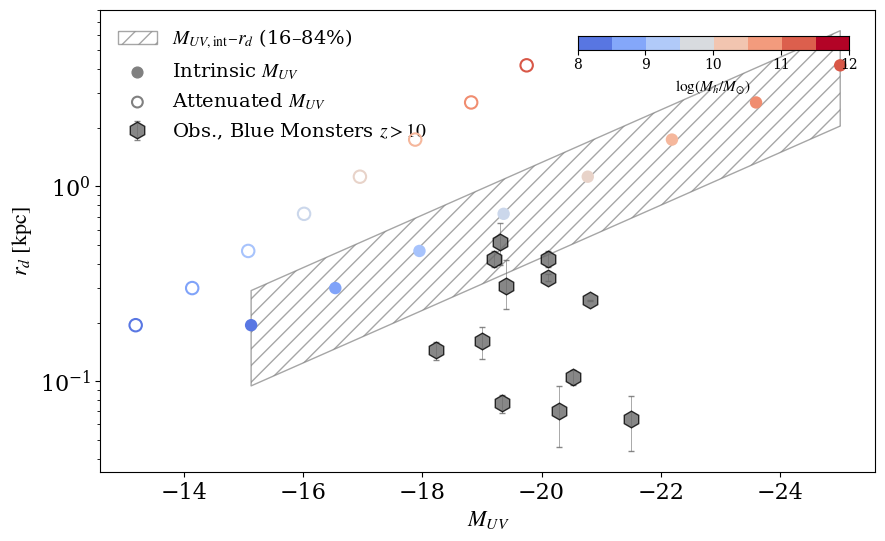

In [100]:
fig, ax = plt.subplots(figsize=(10, 6))

# Recompute intrinsic MUV from Mh_array (8 pts) — independent of fig5's extended _Mh_fig5 grid.
_eps_rd = arr_e[-1]
_muv_intr_rd, _muv_att_mix_rd = [], []
_spin_rd = np.random.lognormal(mean=-3.6, sigma=0.5677, size=1000)
for j in range(len(Mh_array)):
    _sfh, _, _age = star_formation_history(Mh_array[j], redshift, tstep, _eps_rd)
    _l1500 = compute_l1500_steps(l1500_sb99, _age, tstep, _sfh, time_yr_l1500)[-1]
    _muv_intr_rd.append(l1500_to_muv_conv(_l1500))
    _md = compute_mdust_steps(_age, tstep, _sfh, time_yr, log_snr_yr, yd)
    _tau = optical_depth(kuv, _md[1][-1], Mh_array[j], _spin_rd, redshift)
    _muv_att_mix_rd.append(np.median(l1500_to_muv_conv(transmission_sphere_mixed(_tau) * _l1500)))

# Compute rd arrays from disk scale length.
rd_arr, rd_arr_low, rd_arr_up = [], [], []
for j in range(len(Mh_array)):
    rd_arr.append(disk_scale_length(redshift, Mh_array[j], _spin_rd.mean()))
    rd_arr_low.append(disk_scale_length(redshift, Mh_array[j], np.percentile(_spin_rd, 16)))
    rd_arr_up.append(disk_scale_length(redshift, Mh_array[j], np.percentile(_spin_rd, 84)))

# Plot points (colored by Mh).
for j in range(len(Mh_array)):
    col = custom_colormap(float(j) / len(Mh_array))
    ax.scatter(_muv_intr_rd[j], rd_arr[j], color=col, edgecolor="none", s=80, zorder=5)
    ax.scatter(_muv_att_mix_rd[j], rd_arr[j], facecolors="none", edgecolors=col, linewidths=1.5, s=80, zorder=6)

# 16-84% hatched band
ax.fill_between(
    _muv_intr_rd,
    rd_arr_up,
    rd_arr_low,
    edgecolor="grey",
    hatch="//",
    facecolor="none",
    alpha=0.7,
    label=r"$M_{UV,\rm int}$–$r_d$ (16–84%)",
    zorder=1,
)

# Observations (JWST z>=10 sample).
obs = jwst[
    np.isfinite(jwst["MUV"])
    & np.isfinite(jwst["re_pc"])
    & np.isfinite(jwst["err_re_low"])
    & np.isfinite(jwst["err_re_up"])
].copy()

ax.errorbar(
    obs["MUV"],
    1e-3 * obs["re_pc"],
    yerr=[1e-3 * np.abs(obs["err_re_low"]), 1e-3 * np.abs(obs["err_re_up"])],
    label=r"Obs., Blue Monsters $z>10$",
    color="dimgrey",
    mec="black",
    ms=12.0,
    marker="h",
    capsize=2.5,
    elinewidth=0.5,
    alpha=0.8,
    ls="None",
    zorder=7,
)

# Legend handles
ax.scatter([], [], color="grey", s=60, label=r"Intrinsic $M_{UV}$")
ax.scatter([], [], facecolors="none", edgecolors="grey", linewidths=1.5, s=60, label=r"Attenuated $M_{UV}$")

# Inset colorbar for halo mass
log_mh_plot = np.log10(Mh_array)
vmin, vmax = float(np.min(log_mh_plot)), float(np.max(log_mh_plot))
N = max(len(Mh_array), 2)

cax = inset_axes(ax, width="35%", height="3%", loc="upper right", borderpad=1.2)
bar = np.linspace(vmin, vmax, N)[None, :]
cax.imshow(bar, cmap=custom_colormap, extent=(vmin, vmax, 0, 1), aspect="auto", vmin=vmin, vmax=vmax)
cax.set_yticks([])
cax.set_xlabel(r"$\log (M_{h}/M_{\odot})$", fontsize=11, labelpad=4)
cax.tick_params(axis="x", labelsize=10, pad=2)

# Labels and axes
ax.set_xlabel(r"$M_{UV}$")
ax.set_ylabel(r"$r_d\ [\mathrm{kpc}]$")
ax.set_yscale("log")
ax.invert_xaxis()
ax.legend(fontsize=14, loc="best", frameon=False)

print("Saving fig_rd_vs_muv.pdf")
fig.savefig(OUTPUT_DIR / "fig_rd_vs_muv.pdf", bbox_inches="tight")
plt.show()

## Figure -: Kennicutt vs SB99 L1500 Comparison

Compare UV luminosity from:
- **Kennicutt (1998)** calibration: L_UV = 7.14×10^27 × SFR
- **SB99** stellar population synthesis convolved with SFH

Shows that Kennicutt relation is only valid at late times (>100 Myr) in steady-state,
while SB99 captures early evolution accurately.

Saving fig_kennicutt_sb99_comparison.pdf


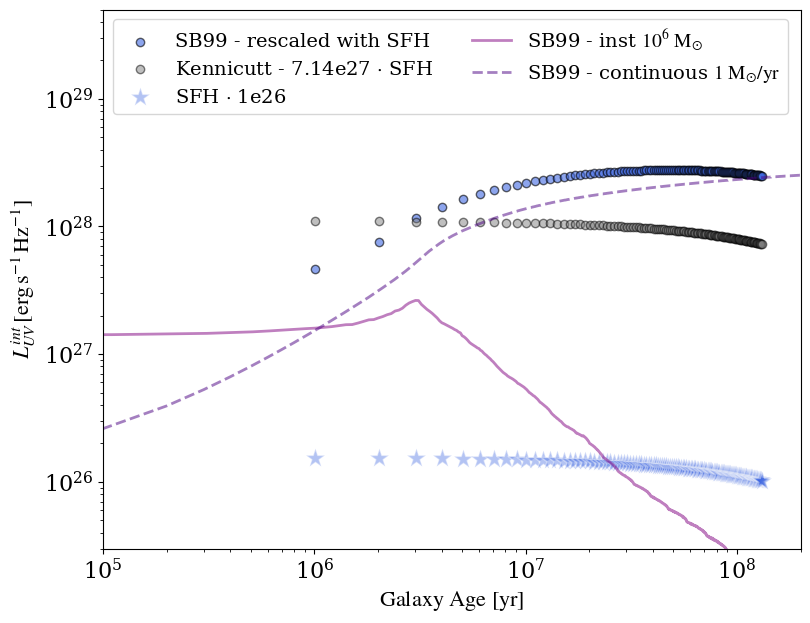

In [101]:
sfh, log_mst_build, age = star_formation_history(Mh_array[3], redshift, tstep, epsilon)

# SB99-convolved UV luminosity along the SFH [erg/s/Hz]
lnu_sb99_arr = compute_l1500_steps(
    l1500=l1500_sb99,
    age=age,
    tstep=tstep,
    sfh=sfh,
    time_yr_l1500=time_yr_l1500,
    method="SB99",
)

# Kennicutt (1998) direct UV conversion [erg/s/Hz]
lnu_ks98_arr = compute_l1500_steps(sfh, method="KS98")

# Convert tabulated SB99 SSP tracks from L_lambda [erg/s/Angstrom] to L_nu [erg/s/Hz]
lnu_sb99_inst = l1500_lambda_to_lnu(10**l1500_sb99)
lnu_sb99_cont = l1500_lambda_to_lnu(10**l1500_sb99_cont)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(age * 1e6, lnu_sb99_arr, color="royalblue", edgecolor="black", label="SB99 - rescaled with SFH", alpha=0.6)
ax.scatter(
    age * 1e6,
    lnu_ks98_arr,
    label=r"Kennicutt - 7.14e27 $\cdot$ SFH",
    alpha=0.5,
    edgecolor="black",
    color="grey",
)
ax.scatter(
    age * 1e6,
    sfh * 1e26,
    label=r"SFH $\cdot$ 1e26",
    alpha=0.4,
    edgecolor="white",
    color="royalblue",
    marker="*",
    s=200,
)
ax.plot(
    time_yr_l1500,
    lnu_sb99_inst,
    label=r"SB99 - inst $10^6\ \mathrm{M_{\odot}}$",
    color="purple",
    lw=2.0,
    alpha=0.5,
)
ax.plot(
    time_yr_l1500_cont,
    lnu_sb99_cont,
    label=r"SB99 - continuous $1\ \mathrm{M_{\odot}/yr}$",
    ls="--",
    color="indigo",
    lw=2.0,
    alpha=0.5,
)

ax.set_xlabel(r"$\mathrm{Galaxy\ Age\ [yr]}$")
ax.set_ylabel(r"$L^{int}_{UV}\,[\mathrm{erg\,s^{-1}\,Hz^{-1}}]$")
ax.set_xlim(1e5, 2e8)
ax.set_ylim(3e25, 5e29)
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(fontsize=14, ncols=2, loc="upper left")
print("Saving fig_kennicutt_sb99_comparison.pdf")
fig.savefig(OUTPUT_DIR / "fig_kennicutt_sb99_comparison.pdf", bbox_inches="tight")
plt.show()